# Process 1 – Sterilization Simulation Explorer

Use this notebook to inspect and correct the simulation output.
Re-run `generate_process_1.py` after tuning parameters in that file, then re-run this notebook.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pm4py
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_vis

DATA_DIR = Path('..') / 'data' / 'gold' / 'experiment_1' / 'process_1' / 'datasets'

df_event_log      = pd.read_parquet(DATA_DIR / 'df_event_log.parquet')
df_expanded       = pd.read_parquet(DATA_DIR / 'df_expanded.parquet')
df_production_plan = pd.read_parquet(DATA_DIR / 'df_production_plan.parquet')

print('Event log:       ', df_event_log.shape)
print('Expanded:        ', df_expanded.shape)
print('Production plan: ', df_production_plan.shape)

Event log:        (7000, 9)
Expanded:         (35065, 18)
Production plan:  (500, 5)


## 1. Event log overview

In [3]:
print('Columns:', df_event_log.dtypes.to_dict())
df_event_log.head(14)

Columns: {'case_id': dtype('O'), 'activity': dtype('O'), 'timestamp_start': dtype('<M8[ns]'), 'timestamp_end': dtype('<M8[ns]'), 'higher_level_activity': dtype('O'), 'station': dtype('O'), 'object_type': dtype('O'), 'object': dtype('O'), 'object_attributes': dtype('O')}


,case_id,activity,timestamp_start,timestamp_end,higher_level_activity,station,object_type,object,object_attributes
0,batch_001,water_supply_prepare,2024-01-15 00:00:00.000000,2024-01-15 00:00:05.559925,sterilization_process,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 463.3}"
1,batch_001,water_supply_working,2024-01-15 00:00:06.559925,2024-01-15 00:01:13.906558,sterilization_process,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 463.3}"
2,batch_001,destillation_heat,2024-01-15 00:01:14.906558,2024-01-15 00:01:47.615250,sterilization_process,Destillation,sterilization_line,destillation,"{'recipe': 'standard', 'volume_L': 463.3}"
3,batch_001,bottling_prepare,2024-01-15 00:01:48.615250,2024-01-15 00:01:54.175175,sterilization_process,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
4,batch_001,bottling_working,2024-01-15 00:01:55.175175,2024-01-15 00:02:32.664783,sterilization_process,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
5,batch_001,bottling_cool,2024-01-15 00:02:33.664783,2024-01-15 00:02:39.224708,sterilization_process,Bottling,sterilization_line,bottling,"{'recipe': 'standard', 'volume_L': 463.3}"
6,batch_001,autoclaving_1_prepare,2024-01-15 00:02:40.224708,2024-01-15 00:04:40.184385,sterilization_process,Autoclaving,sterilization_line,autoclaving_1,"{'recipe': 'standard', 'volume_L': 463.3}"
7,batch_001,autoclaving_1_heat,2024-01-15 00:04:41.184385,2024-01-15 00:22:22.758636,sterilization_process,Autoclaving,sterilization_line,autoclaving_1,"{'recipe': 'standard', 'volume_L': 463.3}"
8,batch_002,water_supply_prepare,2024-01-15 00:15:00.000000,2024-01-15 00:15:02.859484,sterilization_process,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 238.3}"
9,batch_002,water_supply_working,2024-01-15 00:15:03.859484,2024-01-15 00:15:38.156163,sterilization_process,Water_supply,sterilization_line,water_supply,"{'recipe': 'standard', 'volume_L': 238.3}"


In [4]:
# Activity counts per station
(
    df_event_log
    .groupby(['station', 'activity'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values(['station', 'activity'])
)

,station,activity,count
0,Autoclaving,autoclaving_1_cool,169
1,Autoclaving,autoclaving_1_heat,169
2,Autoclaving,autoclaving_1_hold,169
3,Autoclaving,autoclaving_1_prepare,169
4,Autoclaving,autoclaving_2_cool,167
5,Autoclaving,autoclaving_2_heat,167
6,Autoclaving,autoclaving_2_hold,167
7,Autoclaving,autoclaving_2_prepare,167
8,Autoclaving,autoclaving_3_cool,164
9,Autoclaving,autoclaving_3_heat,164


## 2. pm4py Directly-Follows Graph (DFG)

### 2a. Activity-level DFG

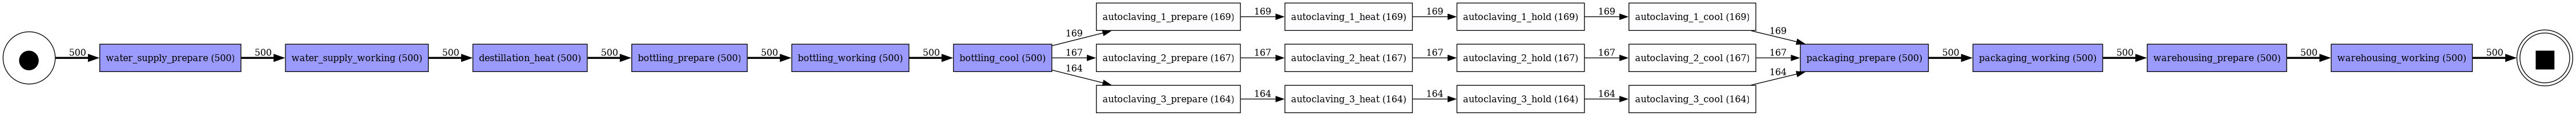

In [5]:
import tempfile
import pandas as pd
import pm4py
from IPython.display import Image, display
from pm4py.visualization.dfg import visualizer as dfg_vis

# Convert to pm4py event log format
el_pm4py = df_event_log.rename(columns={
    "case_id": "case:concept:name",
    "activity": "concept:name",
    "timestamp_start": "time:timestamp",
})

el_pm4py["time:timestamp"] = pd.to_datetime(el_pm4py["time:timestamp"])

log = pm4py.convert_to_event_log(el_pm4py)

dfg, start_acts, end_acts = pm4py.discover_dfg(log)

gviz = dfg_vis.apply(
    dfg,
    log=log,
    variant=dfg_vis.Variants.FREQUENCY,
    parameters={
        "start_activities": start_acts,
        "end_activities": end_acts
    }
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    dfg_vis.save(gviz, f.name)
    display(Image(filename=f.name))

### 2b. Station-level DFG  (higher_level_activity)

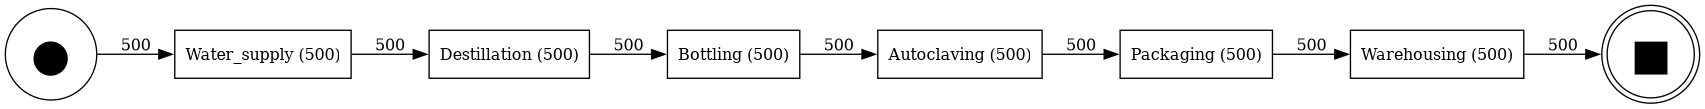

In [6]:
import tempfile
import pandas as pd
import pm4py
from IPython.display import Image, display
from pm4py.visualization.dfg import visualizer as dfg_vis

# Use first event per (case_id, station) as the station-level trace
station_log = (
    df_event_log
    .sort_values("timestamp_start")
    .groupby(["case_id", "station"], sort=False)
    .first()
    .reset_index()
    .rename(columns={
        "case_id": "case:concept:name",
        "station": "concept:name",
        "timestamp_start": "time:timestamp",
    })
)

station_log["time:timestamp"] = pd.to_datetime(station_log["time:timestamp"])

log_station = pm4py.convert_to_event_log(station_log)

dfg_s, sa_s, ea_s = pm4py.discover_dfg(log_station)

gviz_s = dfg_vis.apply(
    dfg_s,
    log=log_station,
    variant=dfg_vis.Variants.FREQUENCY,
    parameters={
        "start_activities": sa_s,
        "end_activities": ea_s
    }
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    dfg_vis.save(gviz_s, f.name)
    display(Image(filename=f.name))

## 3. Process model – Inductive Miner (Petri net)

Petri nets discovered with the **Inductive Miner** give you a formal model of the control flow. A green square = source place (start), a red square = sink place (end), rounded boxes = transitions (activities).

### 3a. Activity-level Petri net

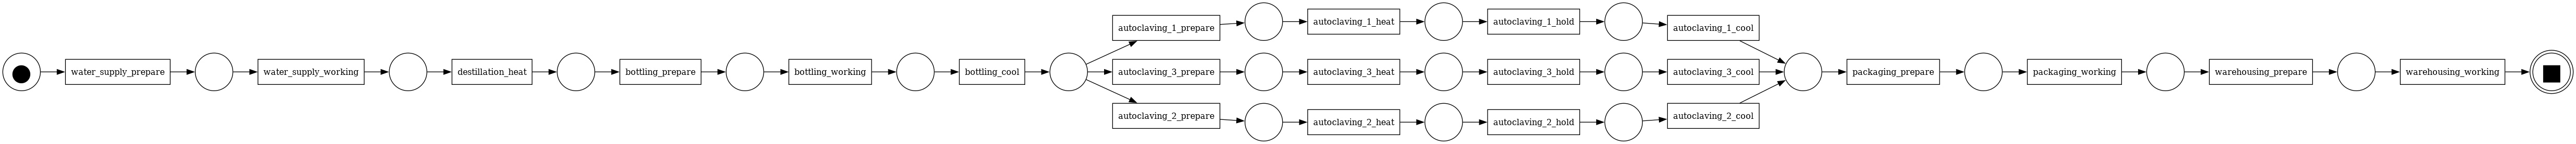

In [7]:
import tempfile
from IPython.display import Image, display
from pm4py.visualization.petri_net import visualizer as pn_vis

# Discover Petri net from the activity-level log
net_a, im_a, fm_a = pm4py.discover_petri_net_inductive(log)

gviz_pn_a = pn_vis.apply(
    net_a,
    im_a,
    fm_a,
    variant=pn_vis.Variants.FREQUENCY,
    parameters={"log": log}
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    pn_vis.save(gviz_pn_a, f.name)
    display(Image(filename=f.name))

### 3b. Station-level Petri net

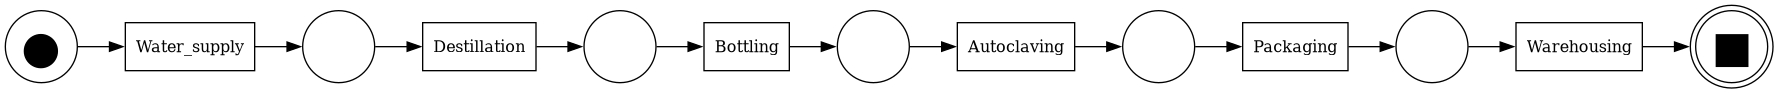

In [8]:
import tempfile
from IPython.display import Image, display
from pm4py.visualization.petri_net import visualizer as pn_vis

# Discover Petri net from the station-level log
net_s, im_s, fm_s = pm4py.discover_petri_net_inductive(log_station)

gviz_pn_s = pn_vis.apply(
    net_s,
    im_s,
    fm_s,
    variant=pn_vis.Variants.FREQUENCY,
    parameters={"log": log_station}
)

with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
    pn_vis.save(gviz_pn_s, f.name)
    display(Image(filename=f.name))

## 3. Duration distributions per station / activity

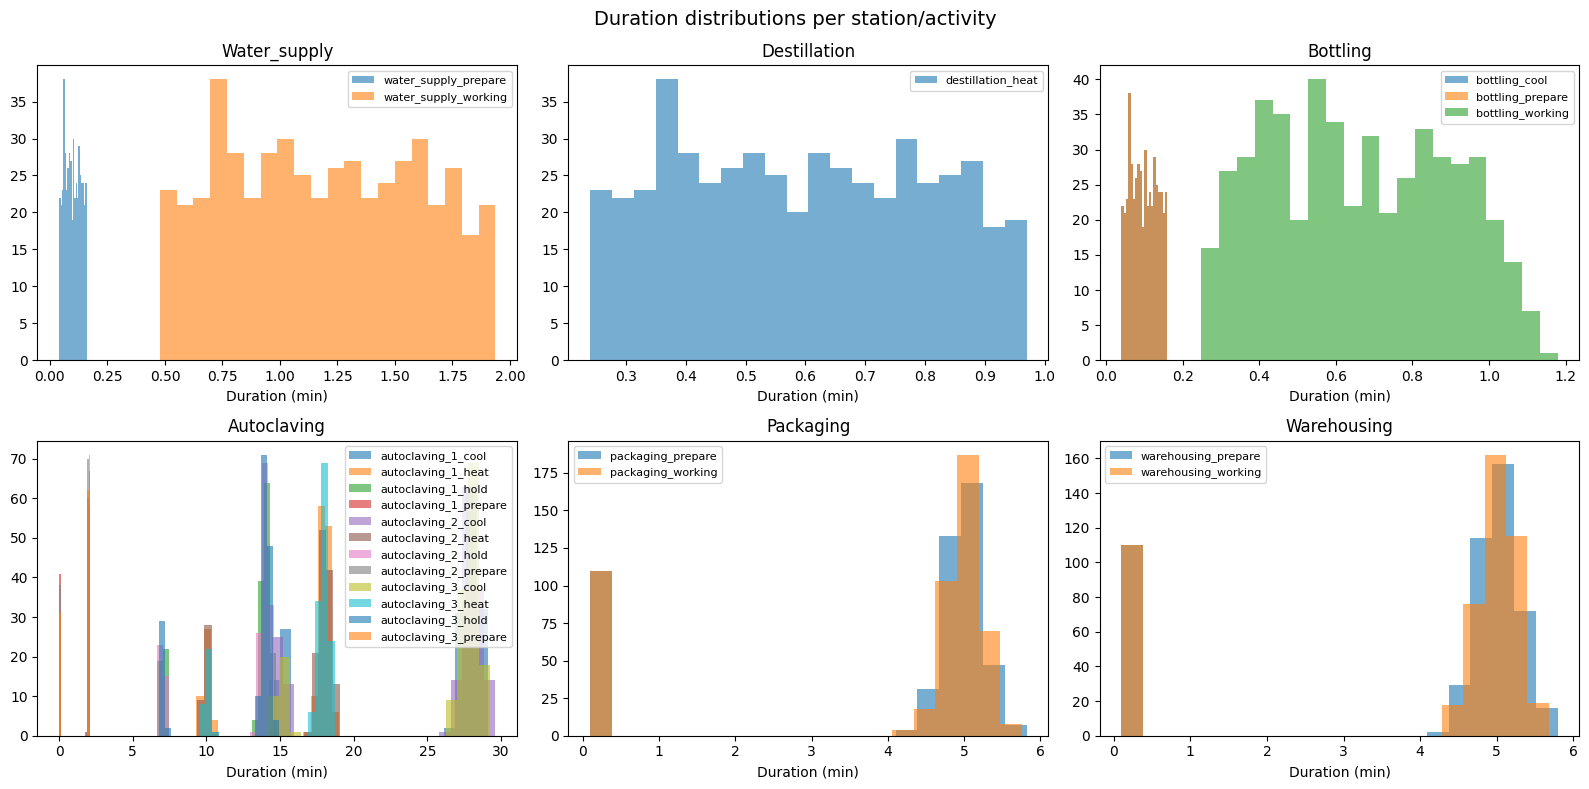

In [9]:
df_event_log['duration_min'] = (
    (df_event_log['timestamp_end'] - df_event_log['timestamp_start'])
    .dt.total_seconds() / 60
)

stations = df_event_log['station'].unique()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, station in zip(axes, stations):
    sub = df_event_log[df_event_log['station'] == station]
    for act, grp in sub.groupby('activity'):
        ax.hist(grp['duration_min'], bins=20, alpha=0.6, label=act)
    ax.set_title(station)
    ax.set_xlabel('Duration (min)')
    ax.legend(fontsize=8)

plt.suptitle('Duration distributions per station/activity', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Gantt chart – batch timeline (first 20 batches)

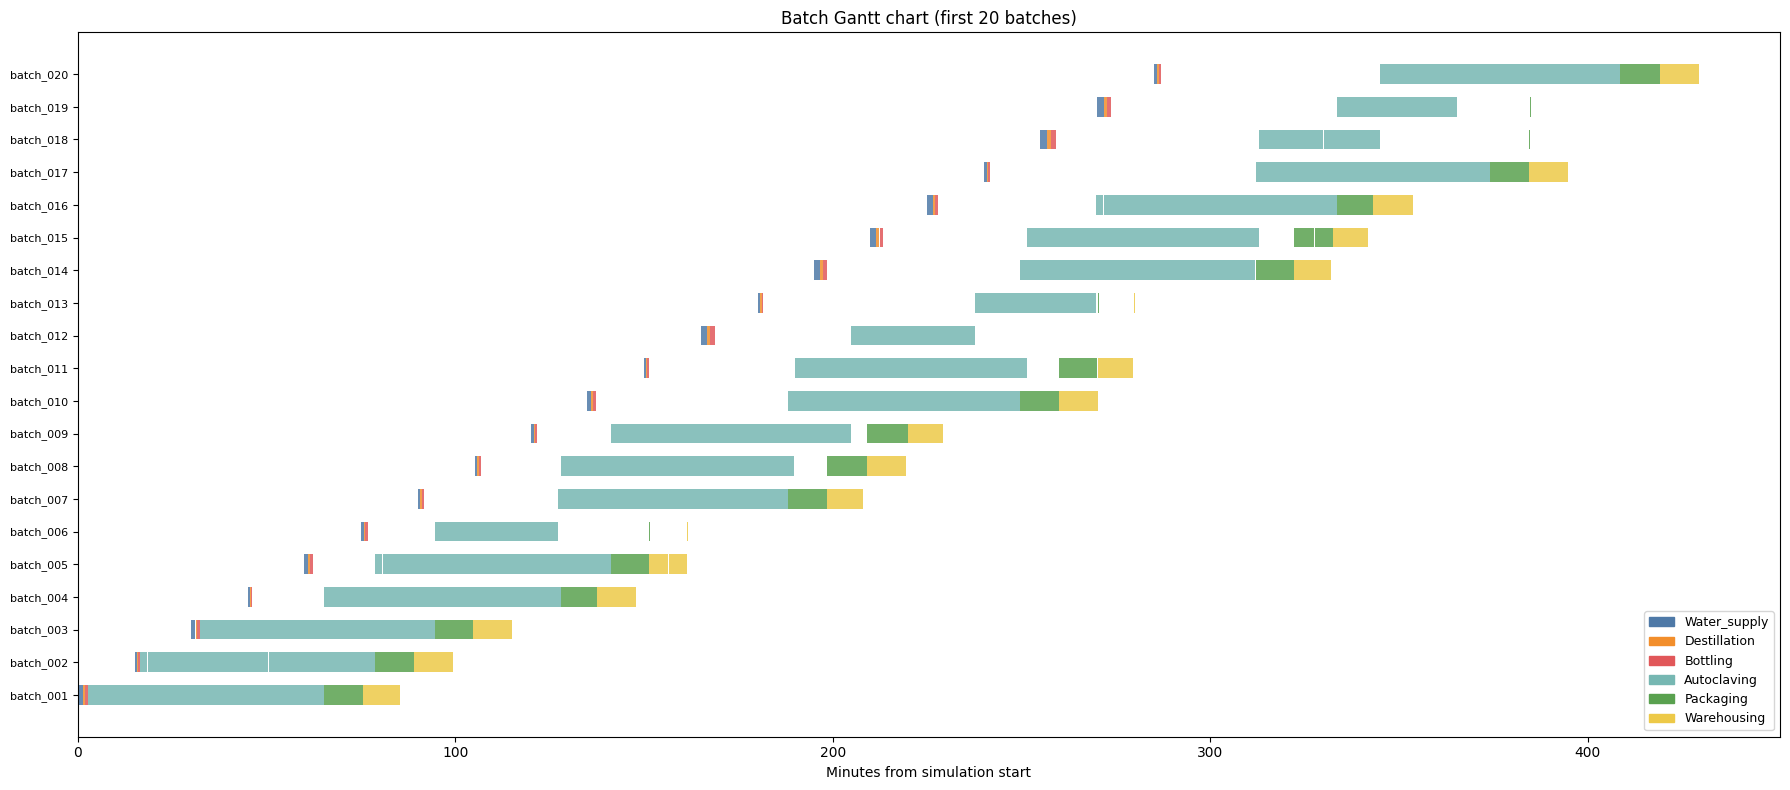

In [10]:
N_GANTT = 20
batches = df_event_log['case_id'].unique()[:N_GANTT]

STATION_COLORS = {
    'Water_supply':  '#4e79a7',
    'Destillation':  '#f28e2b',
    'Bottling':      '#e15759',
    'Autoclaving':   '#76b7b2',
    'Packaging':     '#59a14f',
    'Warehousing':   '#edc948',
}

fig, ax = plt.subplots(figsize=(18, 8))
t0 = df_event_log['timestamp_start'].min()

for yi, bid in enumerate(batches):
    sub = df_event_log[df_event_log['case_id'] == bid]
    for _, row in sub.iterrows():
        start = (row['timestamp_start'] - t0).total_seconds() / 60
        dur   = (row['timestamp_end']   - row['timestamp_start']).total_seconds() / 60
        color = STATION_COLORS.get(row['station'], 'grey')
        ax.barh(yi, dur, left=start, height=0.6, color=color, alpha=0.85)

ax.set_yticks(range(N_GANTT))
ax.set_yticklabels(batches, fontsize=8)
ax.set_xlabel('Minutes from simulation start')
ax.set_title('Batch Gantt chart (first 20 batches)')
patches = [mpatches.Patch(color=c, label=s) for s, c in STATION_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Energy curves – sample batches

Each subplot shows one energy sensor over time, colored by activity.

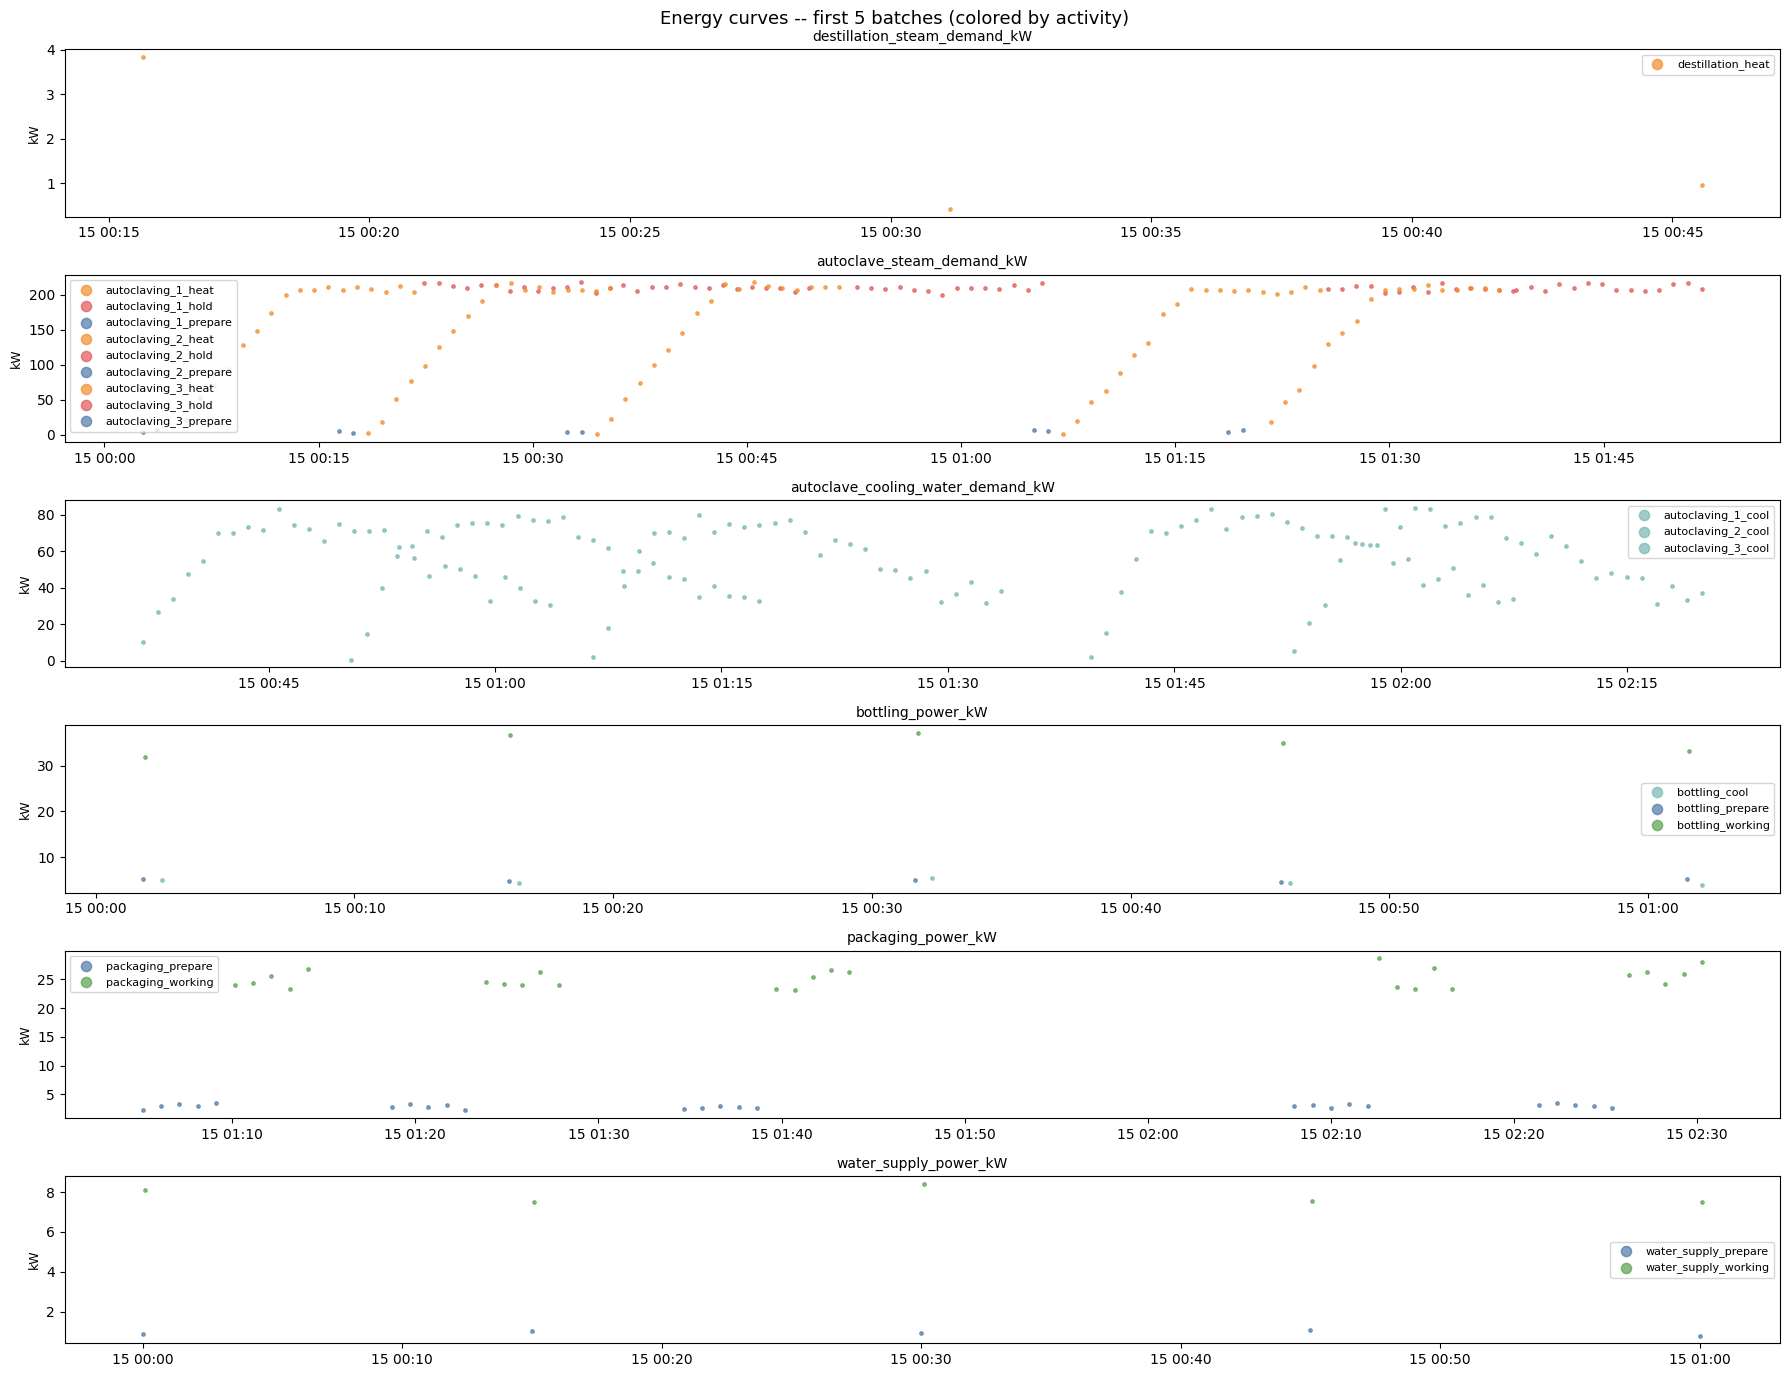

In [11]:
ENERGY_SENSORS = [
    'destillation_steam_demand_kW_energy',
    'autoclave_steam_demand_kW_energy',
    'autoclave_cooling_water_demand_kW_energy',
    'bottling_power_kW_energy',
    'packaging_power_kW_energy',
    'water_supply_power_kW_energy',
]

ACTIVITY_COLORS = {
    'prepare': '#4e79a7',
    'heat':    '#f28e2b',
    'hold':    '#e15759',
    'cool':    '#76b7b2',
    'working': '#59a14f',
}

# Show first 5 batches for clarity
SAMPLE_BATCHES = df_event_log['case_id'].unique()[:5]
sub_exp = df_expanded[df_expanded['case_id_log'].isin(SAMPLE_BATCHES)].copy()

fig, axes = plt.subplots(len(ENERGY_SENSORS), 1, figsize=(18, 14), sharex=False)

for ax, sensor in zip(axes, ENERGY_SENSORS):
    active = sub_exp[sub_exp[sensor] > 0].copy()
    if active.empty:
        ax.set_title(sensor + ' -- no data')
        continue
    for act, grp in active.groupby('activity_log'):
        # activity_log is now 'resource_actname' (e.g. 'autoclaving_1_heat')
        short = act.split('_')[-1]
        color = ACTIVITY_COLORS.get(short, 'grey')
        ax.scatter(grp['datetime_energy'], grp[sensor],
                   s=6, color=color, alpha=0.7, label=act)
    ax.set_ylabel('kW', fontsize=9)
    ax.set_title(sensor.replace('_energy', ''), fontsize=10)
    ax.legend(fontsize=8, markerscale=3)

plt.suptitle('Energy curves -- first 5 batches (colored by activity)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Weather vs. energy – verifying physical relationships

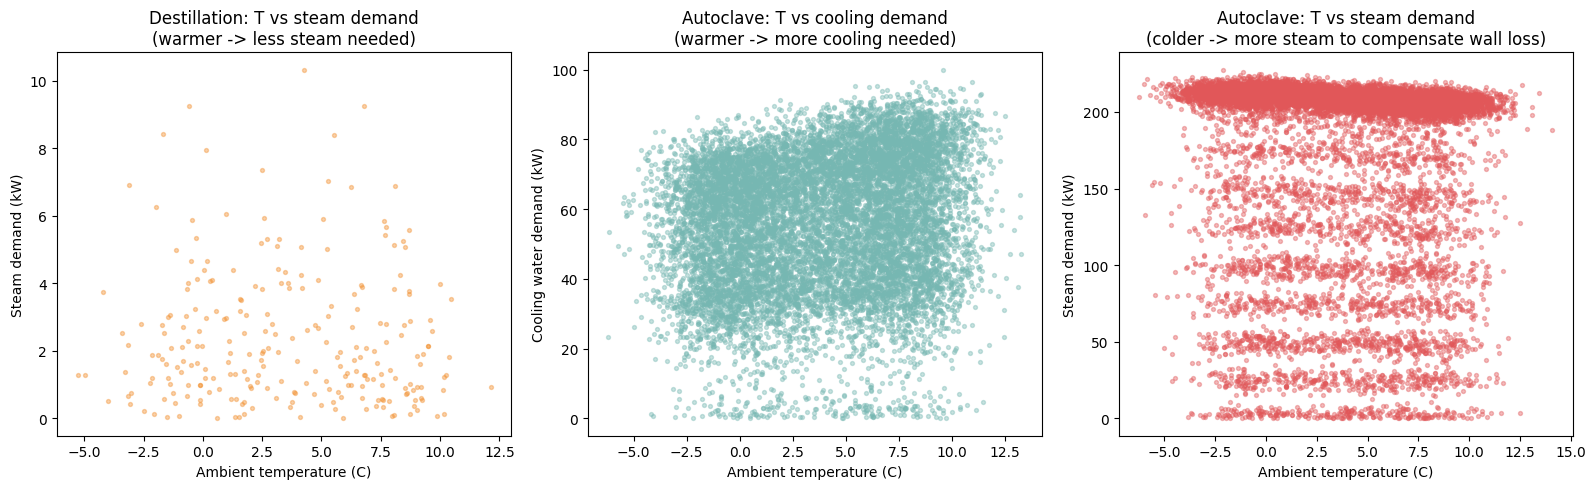

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a. Temperature vs. distillation steam demand
dest = df_expanded[df_expanded['destillation_steam_demand_kW_energy'] > 0]
axes[0].scatter(dest['ef_temperature_2m_energy'],
                dest['destillation_steam_demand_kW_energy'],
                s=8, alpha=0.4, color='#f28e2b')
axes[0].set_xlabel('Ambient temperature (C)')
axes[0].set_ylabel('Steam demand (kW)')
axes[0].set_title('Destillation: T vs steam demand\n(warmer -> less steam needed)')

# 6b. Temperature vs. autoclave cooling water demand (cool phase only)
cool = df_expanded[
    (df_expanded['autoclave_cooling_water_demand_kW_energy'] > 0) &
    (df_expanded['activity_log'].str.endswith('_cool'))
]
axes[1].scatter(cool['ef_temperature_2m_energy'],
                cool['autoclave_cooling_water_demand_kW_energy'],
                s=8, alpha=0.4, color='#76b7b2')
axes[1].set_xlabel('Ambient temperature (C)')
axes[1].set_ylabel('Cooling water demand (kW)')
axes[1].set_title('Autoclave: T vs cooling demand\n(warmer -> more cooling needed)')

# 6c. Temperature vs. autoclave steam demand (heat + hold)
steam = df_expanded[
    (df_expanded['autoclave_steam_demand_kW_energy'] > 0) &
    (df_expanded['activity_log'].str.endswith(('_heat', '_hold')))
]
axes[2].scatter(steam['ef_temperature_2m_energy'],
                steam['autoclave_steam_demand_kW_energy'],
                s=8, alpha=0.4, color='#e15759')
axes[2].set_xlabel('Ambient temperature (C)')
axes[2].set_ylabel('Steam demand (kW)')
axes[2].set_title('Autoclave: T vs steam demand\n(colder -> more steam to compensate wall loss)')

plt.tight_layout()
plt.show()

## 7. Weather time series over the simulation period

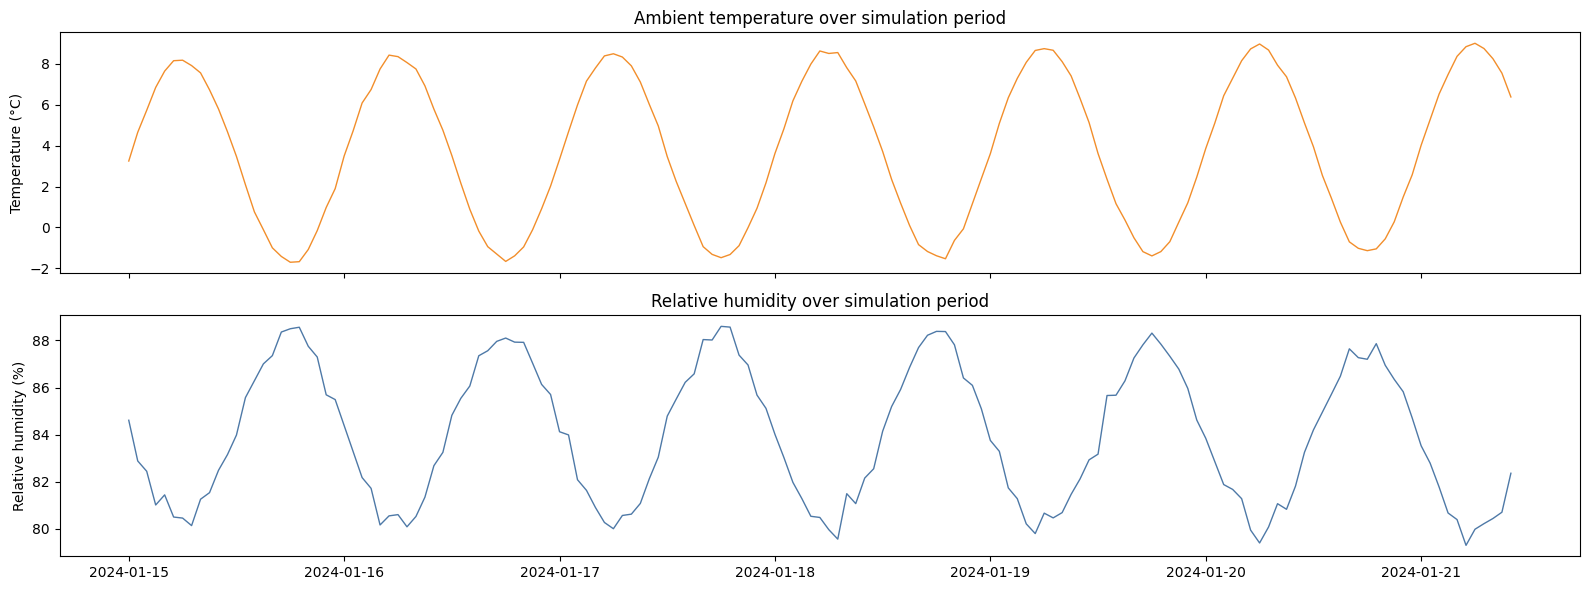

In [13]:
weather = (
    df_expanded
    .set_index('datetime_energy')[['ef_temperature_2m_energy', 'ef_relative_humidity_2m_energy']]
    .resample('1h').mean()
    .dropna()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

ax1.plot(weather.index, weather['ef_temperature_2m_energy'], color='#f28e2b', lw=1)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Ambient temperature over simulation period')

ax2.plot(weather.index, weather['ef_relative_humidity_2m_energy'], color='#4e79a7', lw=1)
ax2.set_ylabel('Relative humidity (%)')
ax2.set_title('Relative humidity over simulation period')

plt.tight_layout()
plt.show()

## 8. Autoclave load – how many autoclave resources run in parallel

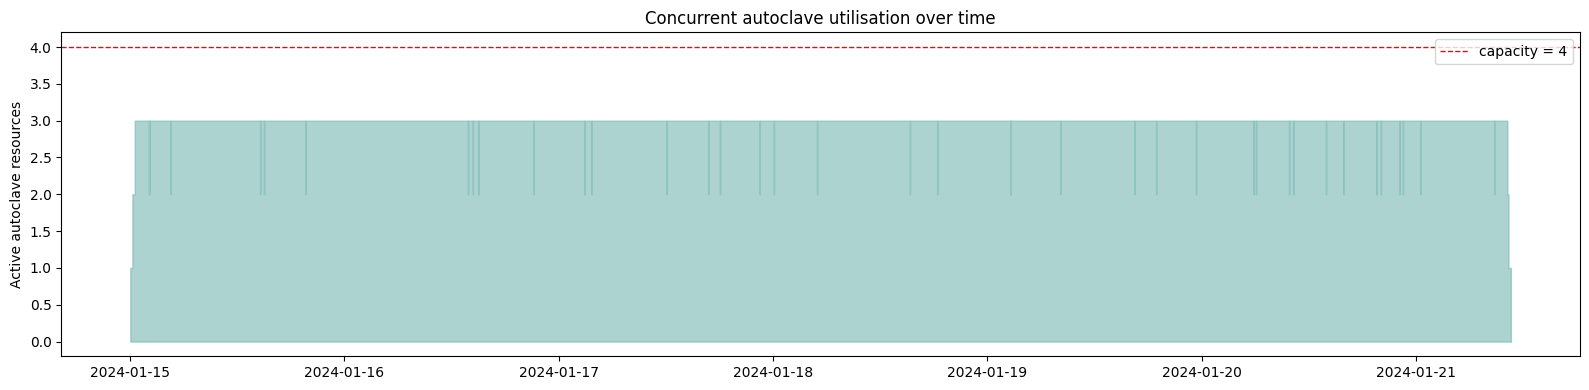

In [14]:
ac_events = df_event_log[df_event_log['station'] == 'Autoclaving'].copy()

# Build 1-minute timeline of concurrent autoclave usage
t_min = ac_events['timestamp_start'].min().floor('min')
t_max = ac_events['timestamp_end'].max().ceil('min')
timeline = pd.date_range(t_min, t_max, freq='min')

concurrent = np.zeros(len(timeline))
for _, row in ac_events.iterrows():
    mask = (timeline >= row['timestamp_start']) & (timeline < row['timestamp_end'])
    concurrent[mask] += 1

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(timeline, concurrent, step='pre', alpha=0.6, color='#76b7b2')
ax.set_ylabel('Active autoclave resources')
ax.set_title('Concurrent autoclave utilisation over time')
ax.axhline(4, color='red', linestyle='--', lw=1, label='capacity = 4')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Expanded dataset overview

In [15]:
df_expanded.head(5)

,datetime_energy,ef_temperature_2m_energy,ef_relative_humidity_2m_energy,destillation_steam_demand_kW_energy,autoclave_steam_demand_kW_energy,autoclave_cooling_water_demand_kW_energy,bottling_power_kW_energy,packaging_power_kW_energy,water_supply_power_kW_energy,timestamp_start_log,timestamp_end_log,activity_log,higher_level_activity_log,station_log,object_type_log,object_log,case_id_log,object_attributes_log
0,2024-01-15 00:00:00.000000,1.941789,75.487378,0.0,0.0,0.0,0.000000,0.0,0.882894,2024-01-15 00:00:00.000000,2024-01-15 00:00:05.559925,water_supply_prepare,sterilization_process,Water_supply,sterilization_line,water_supply,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
1,2024-01-15 00:00:06.559925,2.129406,91.428965,0.0,0.0,0.0,0.000000,0.0,8.102866,2024-01-15 00:00:06.559925,2024-01-15 00:01:13.906558,water_supply_working,sterilization_process,Water_supply,sterilization_line,water_supply,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
2,2024-01-15 00:01:14.906558,2.769762,80.791063,0.0,0.0,0.0,0.000000,0.0,0.000000,2024-01-15 00:01:14.906558,2024-01-15 00:01:47.615250,destillation_heat,sterilization_process,Destillation,sterilization_line,destillation,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
3,2024-01-15 00:01:48.615250,2.765596,83.017738,0.0,0.0,0.0,5.292771,0.0,0.000000,2024-01-15 00:01:48.615250,2024-01-15 00:01:54.175175,bottling_prepare,sterilization_process,Bottling,sterilization_line,bottling,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"
4,2024-01-15 00:01:55.175175,3.854121,73.527360,0.0,0.0,0.0,31.864168,0.0,0.000000,2024-01-15 00:01:55.175175,2024-01-15 00:02:32.664783,bottling_working,sterilization_process,Bottling,sterilization_line,bottling,batch_001,"{'recipe': 'standard', 'volume_L': 463.3}"


In [16]:
# Summary stats for energy sensors
sensors = [
    'destillation_steam_demand_kW_energy',
    'autoclave_steam_demand_kW_energy',
    'autoclave_cooling_water_demand_kW_energy',
    'bottling_power_kW_energy',
    'packaging_power_kW_energy',
    'water_supply_power_kW_energy',
]
# Only non-zero rows per sensor
summary = {}
for s in sensors:
    d = df_expanded[df_expanded[s] > 0][s]
    summary[s] = {'n_rows': len(d), 'mean': d.mean(), 'std': d.std(),
                  'min': d.min(), 'max': d.max()}
pd.DataFrame(summary).T.round(2)

,n_rows,mean,std,min,max
destillation_steam_demand_kW_energy,249.0,2.36,1.98,0.00,10.33
autoclave_steam_demand_kW_energy,15012.0,169.96,68.86,0.00,227.67
autoclave_cooling_water_demand_kW_energy,12311.0,56.32,18.92,0.00,100.04
bottling_power_kW_energy,1500.0,14.97,14.19,3.43,43.29
packaging_power_kW_energy,4116.0,14.01,11.06,1.85,30.88
water_supply_power_kW_energy,1140.0,4.93,3.51,0.43,9.62


# 10. Conformance Diagnosis — Petri net approaches (no energy models)

Train/test split → mine Petri net from train → simulate on test → compute the exact same
conformance metrics as `modelling.py` to diagnose why precision = 0 for process_1.

## Metric guide

### Part A — Process model quality (Petri net vs real log)
These measure how well the mined Petri net captures the real process.
They do **not** involve the simulation output.

| Metric | What it measures | How to read it |
|--------|-----------------|----------------|
| **Fitness** | Can every event trace in the log be replayed by the Petri net without token errors? | 1.0 = all traces follow the model exactly. <0.8 = model is missing real behaviour the net cannot explain. |
| **Precision** | Does the net over-allow behaviour that never appears in the log? | 1.0 = net permits only what was observed. 0.4 = at each replay step the net enables ~2.5x more transitions than actually fired — the model is too permissive. |
| **Generalization** | Is the net overfitted to training traces? | ~0.9 = good. Penalises transitions that are rarely exercised relative to their maximum possible use. Computed on training log; same value reported for test (it is a net property, not a data property). |
| **Simplicity** | Structural complexity of the Petri net. | 1 / (1 + 0.005 x (places + transitions + arcs)). A 4-step sequential net ~0.92; a spaghetti net with loops scores lower. |

*Evaluated per station: each station's net is replayed only against that station's own events.*

---

### Part B — Simulation output vs real log (direct comparison)
These measure how closely the simulation's **generated events** match **reality**.
They compare `sim_log` directly to `df_train` or `df_test` — no Petri net involved.

| Metric | What it measures | How to read it | Ideal |
|--------|-----------------|----------------|-------|
| **Event ratio** | `len(sim_log) / len(real_log)` — does the sim produce the right number of events? | 1.0 = exact. >1 = sim over-generates; <1 = sim under-generates. ~2.14 here because the sim fires all resource objects per batch, not just one. | 1.0 |
| **Mean duration error** | `|sim_mean_duration - real_mean_duration| / real_mean_duration` | 0.0 = sim durations match reality on average. 0.2 = off by 20%. | 0.0 |
| **Median duration error** | Same but using medians — more robust to outlier activities. | 0.0 = perfect match. | 0.0 |
| **Activity dist (JS div)** | Jensen-Shannon divergence between the activity frequency distributions of sim and real. | 0.0 = identical distributions. 1.0 = completely different. Tells you if the sim generates the same mix of activities as reality. | 0.0 |
| **DFG edge precision** | Of all (A->B) directly-follows pairs in the sim log, what fraction also appear in the real log? | 1.0 = every sequence the sim generates was also seen in reality. Low = sim invents sequences that never happen. | 1.0 |
| **DFG edge recall** | Of all (A->B) pairs in the real log, what fraction also appear in the sim log? | 1.0 = sim reproduces all real sequences. Low = sim misses sequences that do happen in reality. | 1.0 |
| **DFG edge F1** | Harmonic mean of edge precision and recall. Single summary of control-flow similarity. | 1.0 = sim and reality have identical process flow. | 1.0 |

---

### Known artefacts

**Event ratio ~2.14 (structural):** `ProcessSimulation` runs each batch through every resource object (all 4 autoclaves + 7 others = ~30 events/batch). In reality each batch uses one autoclave only (~14 events/batch). This inflates event count, JS div, and DFG edge metrics.

**Precision = 1.0 (correct):** Evaluating each station's net against its own station-filtered log gives 1.0. The old 0.4 artefact came from evaluating the autoclaving net against the full 14-activity cross-station log.


In [17]:
import sys
sys.path.insert(0, str(Path('.').resolve()))

from sim_extractor import extract_process
from simulation import ProcessSimulation
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from scipy.spatial.distance import jensenshannon

try:
    from pm4py.algo.evaluation.generalization import algorithm as _pm4py_gen
except Exception:
    _pm4py_gen = None

try:
    from pm4py.algo.evaluation.simplicity import algorithm as _pm4py_sim
except Exception:
    _pm4py_sim = None

def _fitness(log_pm4py, net, im, fm):
    replay = token_replay.apply(log_pm4py, net, im, fm,
                                parameters={'consider_remaining_in_fitness': True})
    scores = [float(r['trace_fitness']) for r in replay
              if 'trace_fitness' in r and r['trace_fitness'] is not None]
    return float(np.mean(scores)) if scores else np.nan

def _precision(log_pm4py, net, im, fm):
    return float(pm4py.precision_token_based_replay(log_pm4py, net, im, fm))

def _generalization(log_pm4py, net, im, fm):
    if _pm4py_gen is None:
        return np.nan
    return float(_pm4py_gen.apply(log_pm4py, net, im, fm))

def _simplicity(net):
    if _pm4py_sim is not None:
        return float(_pm4py_sim.apply(net))
    complexity = len(net.places) + len(net.transitions) + len(net.arcs)
    return float(1.0 / (1.0 + 0.005 * float(complexity)))

def to_pm4py_log(df):
    el = df.rename(columns={
        'case_id': 'case:concept:name',
        'activity': 'concept:name',
        'timestamp_start': 'time:timestamp',
    })[['case:concept:name', 'concept:name', 'time:timestamp']].copy()
    el['time:timestamp'] = pd.to_datetime(el['time:timestamp'])
    return pm4py.convert_to_event_log(el)

def _format_df(df):
    return pm4py.format_dataframe(
        df.dropna(subset=['case_id', 'activity', 'timestamp_start']),
        case_id='case_id', activity_key='activity', timestamp_key='timestamp_start')

def _compute_event_ratio(sim_df, real_df):
    return float(len(sim_df) / len(real_df)) if len(real_df) > 0 else np.nan

def _compute_duration_errors(sim_df, real_df):
    s = (sim_df['timestamp_end'] - sim_df['timestamp_start']).dt.total_seconds().dropna()
    r = (real_df['timestamp_end'] - real_df['timestamp_start']).dt.total_seconds().dropna()
    if len(s) == 0 or len(r) == 0:
        return np.nan, np.nan
    mean_err   = abs(s.mean()   - r.mean())   / r.mean()   if r.mean()   != 0 else np.nan
    median_err = abs(s.median() - r.median()) / r.median() if r.median() != 0 else np.nan
    return float(mean_err), float(median_err)

def _compute_js_divergence(sim_df, real_df):
    s_freq = sim_df['activity'].value_counts(normalize=True)
    r_freq = real_df['activity'].value_counts(normalize=True)
    acts   = sorted(set(s_freq.index) | set(r_freq.index))
    s_vec  = np.array([s_freq.get(a, 0.0) for a in acts])
    r_vec  = np.array([r_freq.get(a, 0.0) for a in acts])
    return float(jensenshannon(s_vec, r_vec))

def _compute_activity_duration_errors(sim_df, real_df):
    """Per-activity mean duration error averaged across common activities."""
    real_dur = real_df.copy()
    real_dur['dur'] = (real_dur['timestamp_end'] - real_dur['timestamp_start']).dt.total_seconds()
    sim_dur = sim_df.copy()
    sim_dur['dur'] = (sim_dur['timestamp_end'] - sim_dur['timestamp_start']).dt.total_seconds()
    real_mean = real_dur.groupby('activity')['dur'].mean()
    sim_mean  = sim_dur.groupby('activity')['dur'].mean()
    common = real_mean.index.intersection(sim_mean.index)
    if len(common) == 0:
        return np.nan
    errs = [abs(sim_mean[a] - real_mean[a]) / real_mean[a]
            for a in common if real_mean[a] != 0]
    return float(np.mean(errs)) if errs else np.nan

def _compute_edge_metrics(sim_df, real_df):
    sim_fmt  = _format_df(sim_df)
    real_fmt = _format_df(real_df)
    sim_dfg,  _, _ = pm4py.discover_dfg(sim_fmt)
    real_dfg, _, _ = pm4py.discover_dfg(real_fmt)
    sim_edges  = set(sim_dfg.keys())
    real_edges = set(real_dfg.keys())
    if not sim_edges or not real_edges:
        return np.nan, np.nan, np.nan
    prec = len(sim_edges & real_edges) / len(sim_edges)
    rec  = len(sim_edges & real_edges) / len(real_edges)
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return float(prec), float(rec), float(f1)

# 50/50 temporal split
_all_cases = (df_event_log.sort_values('timestamp_start')
                           .groupby('case_id')['timestamp_start'].min()
                           .sort_values().index.tolist())
_n_train    = max(1, len(_all_cases) // 2)
_train_cases = set(_all_cases[:_n_train])
_test_cases  = set(_all_cases[_n_train:])

df_train = df_event_log[df_event_log['case_id'].isin(_train_cases)].copy()
df_test  = df_event_log[df_event_log['case_id'].isin(_test_cases)].copy()

print(f'Train: {len(_train_cases)} cases / {len(df_train)} events')
print(f'Test:  {len(_test_cases)} cases  / {len(df_test)} events')

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.

Train: 250 cases / 3500 events
Test:  250 cases  / 3500 events



  ALGORITHM: INDUCTIVE

Processing: sterilization_process (8 objects, one whole-process net)
  Mining algorithm: inductive
  Found 22 unique activities: ['water_supply_prepare' 'water_supply_working' 'destillation_heat'
 'bottling_prepare' 'bottling_working' 'bottling_cool'
 'autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_2_prepare'
 'autoclaving_2_heat' 'autoclaving_1_hold' 'autoclaving_3_prepare'
 'autoclaving_3_heat' 'autoclaving_2_hold' 'autoclaving_1_cool'
 'autoclaving_2_cool' 'autoclaving_3_hold' 'packaging_prepare'
 'autoclaving_3_cool' 'packaging_working' 'warehousing_prepare'
 'warehousing_working']
    water_supply_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
    water_supply_working: best fit = weibull_min (3.307345386537942, 0.0, 1.3267222301619117)
    destillation_heat: best fit = weibull_min (3.2903830188083383, 0.0, 0.663379508518636)
    bottling_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
 

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9668, fitness=1.0000, precision=1.0000, generalization=0.9114997548898552, simplicity=0.9555555555555555
    Selected params: noise=0.2, heur={} (score=0.9668)
    Petri net: 21 places, 22 transitions, 44 arcs


...

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]


  [A] Conformance (1 net(s)):
    TRAIN  fitness=1.000  precision=1.000  generalization=0.911  simplicity=0.956
    TEST   fitness=1.000  precision=1.000  generalization=0.911  simplicity=0.956
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 1
Building config from 22 activities:
  Config: ('water_supply_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'water_supply_working': 1.0}
    Start: True
  Config: ('water_supply_working', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'destillation_heat': 1.0}
    Start: False
  Config: ('destillation_heat', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_prepare': 1.0}
    Start: False
  Config: ('bottling_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_working': 1.0}
    Start: False
  Config: ('bottli

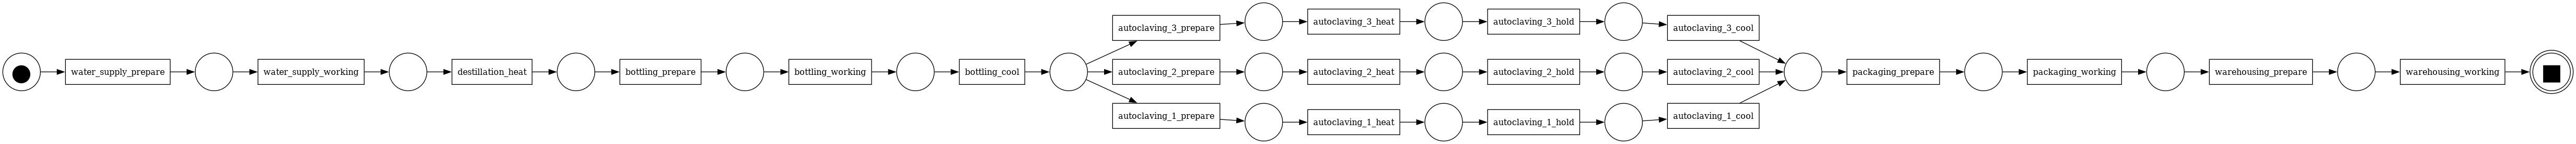


  DFG — REAL TEST SET (inductive):


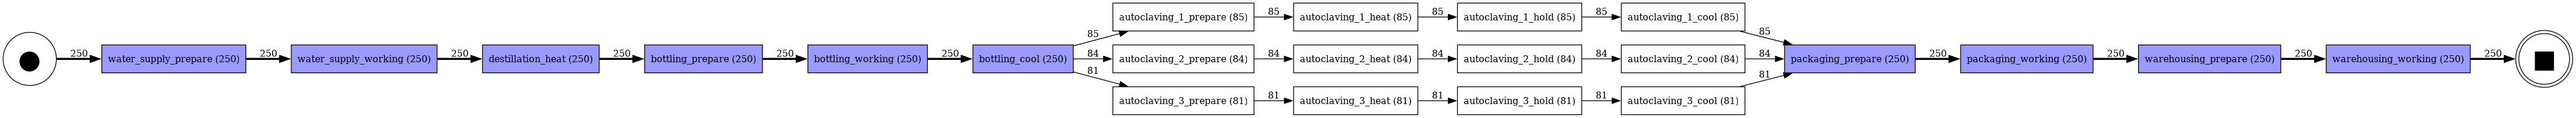


  DFG — SIMULATED LOG (inductive):


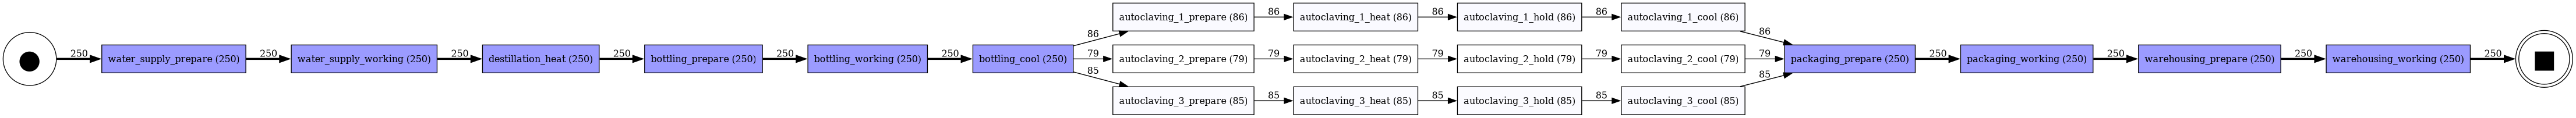


  ALGORITHM: HEURISTIC

Processing: sterilization_process (8 objects, one whole-process net)
  Mining algorithm: heuristic
  Found 22 unique activities: ['water_supply_prepare' 'water_supply_working' 'destillation_heat'
 'bottling_prepare' 'bottling_working' 'bottling_cool'
 'autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_2_prepare'
 'autoclaving_2_heat' 'autoclaving_1_hold' 'autoclaving_3_prepare'
 'autoclaving_3_heat' 'autoclaving_2_hold' 'autoclaving_1_cool'
 'autoclaving_2_cool' 'autoclaving_3_hold' 'packaging_prepare'
 'autoclaving_3_cool' 'packaging_working' 'warehousing_prepare'
 'warehousing_working']
    water_supply_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
    water_supply_working: best fit = weibull_min (3.307345386537942, 0.0, 1.3267222301619117)
    destillation_heat: best fit = weibull_min (3.2903830188083383, 0.0, 0.663379508518636)
    bottling_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
 

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9668, fitness=1.0000, precision=1.0000, generalization=0.9114997548898552, simplicity=0.9555555555555555
    Selected params: noise=0.2, heur={} (score=0.9668)
    Petri net: 21 places, 22 transitions, 44 arcs


...

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]


  [A] Conformance (1 net(s)):
    TRAIN  fitness=1.000  precision=1.000  generalization=0.911  simplicity=0.956
    TEST   fitness=1.000  precision=1.000  generalization=0.911  simplicity=0.956
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 1
Building config from 22 activities:
  Config: ('water_supply_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'water_supply_working': 1.0}
    Start: True
  Config: ('water_supply_working', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'destillation_heat': 1.0}
    Start: False
  Config: ('destillation_heat', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_prepare': 1.0}
    Start: False
  Config: ('bottling_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_working': 1.0}
    Start: False
  Config: ('bottli

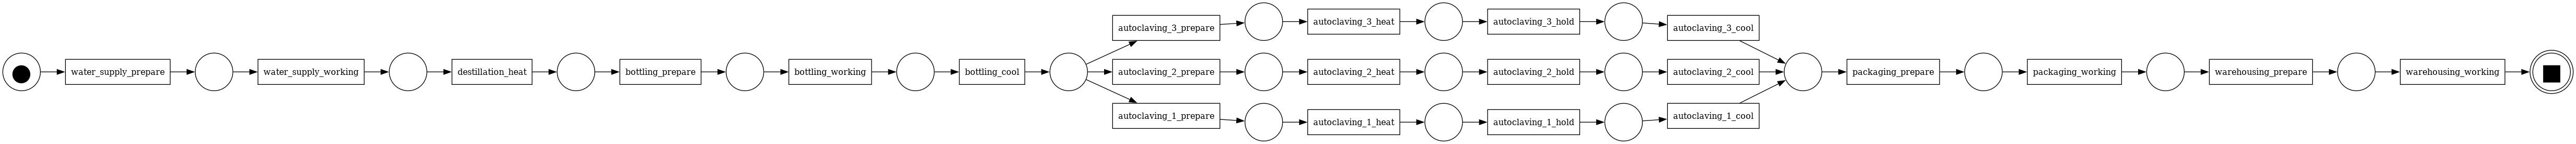


  DFG — REAL TEST SET (heuristic):


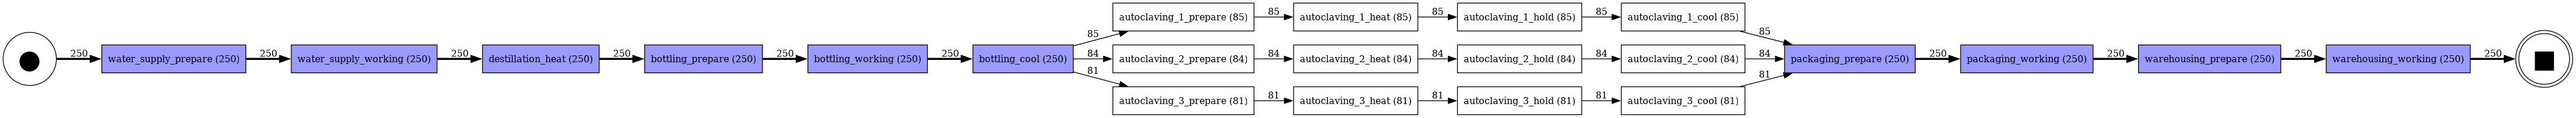


  DFG — SIMULATED LOG (heuristic):


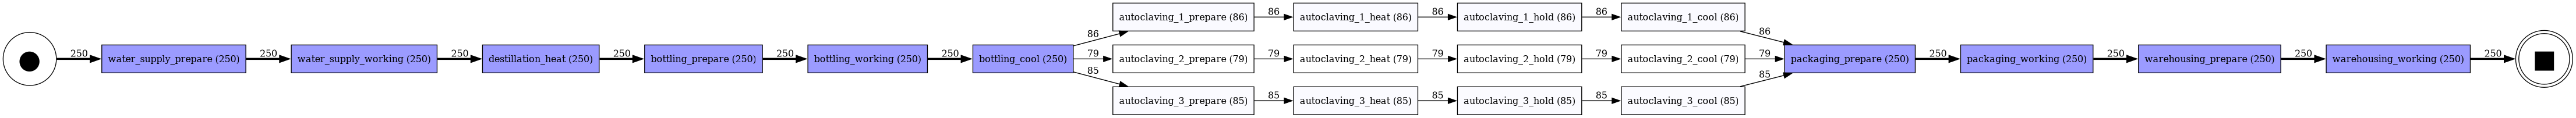


  ALGORITHM: ALPHA

Processing: sterilization_process (8 objects, one whole-process net)
  Mining algorithm: alpha
  Found 22 unique activities: ['water_supply_prepare' 'water_supply_working' 'destillation_heat'
 'bottling_prepare' 'bottling_working' 'bottling_cool'
 'autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_2_prepare'
 'autoclaving_2_heat' 'autoclaving_1_hold' 'autoclaving_3_prepare'
 'autoclaving_3_heat' 'autoclaving_2_hold' 'autoclaving_1_cool'
 'autoclaving_2_cool' 'autoclaving_3_hold' 'packaging_prepare'
 'autoclaving_3_cool' 'packaging_working' 'warehousing_prepare'
 'warehousing_working']
    water_supply_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
    water_supply_working: best fit = weibull_min (3.307345386537942, 0.0, 1.3267222301619117)
    destillation_heat: best fit = weibull_min (3.2903830188083383, 0.0, 0.663379508518636)
    bottling_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
    bottl

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9668, fitness=1.0000, precision=1.0000, generalization=0.9114997548898552, simplicity=0.9555555555555555
    Selected params: noise=0.2, heur={} (score=0.9668)
    Petri net: 21 places, 22 transitions, 44 arcs


...

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]


  [A] Conformance (1 net(s)):
    TRAIN  fitness=1.000  precision=1.000  generalization=0.911  simplicity=0.956
    TEST   fitness=1.000  precision=1.000  generalization=0.911  simplicity=0.956
[DEBUG __init__] mode=petri_net, process_models is None: False, process_models len: 1
Building config from 22 activities:
  Config: ('water_supply_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'water_supply_working': 1.0}
    Start: True
  Config: ('water_supply_working', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'destillation_heat': 1.0}
    Start: False
  Config: ('destillation_heat', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_prepare': 1.0}
    Start: False
  Config: ('bottling_prepare', 'sterilization_process', 'sterilization_line', 'sterilization_process')
    Transitions: {'bottling_working': 1.0}
    Start: False
  Config: ('bottli

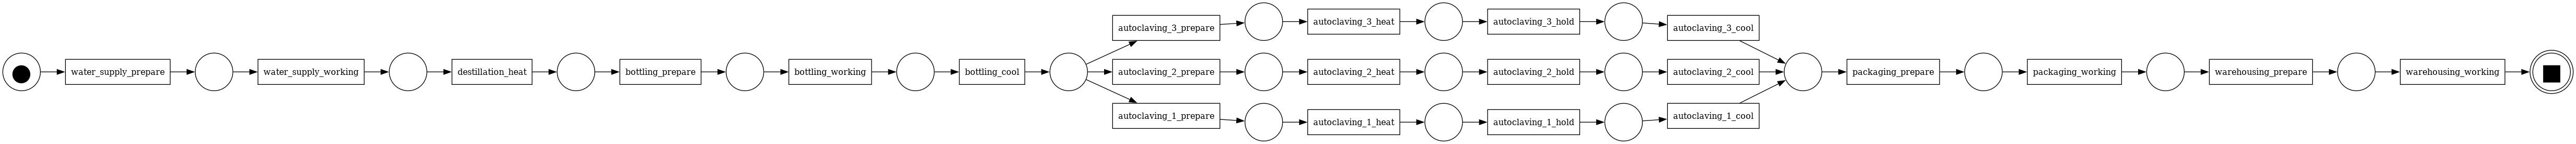


  DFG — REAL TEST SET (alpha):


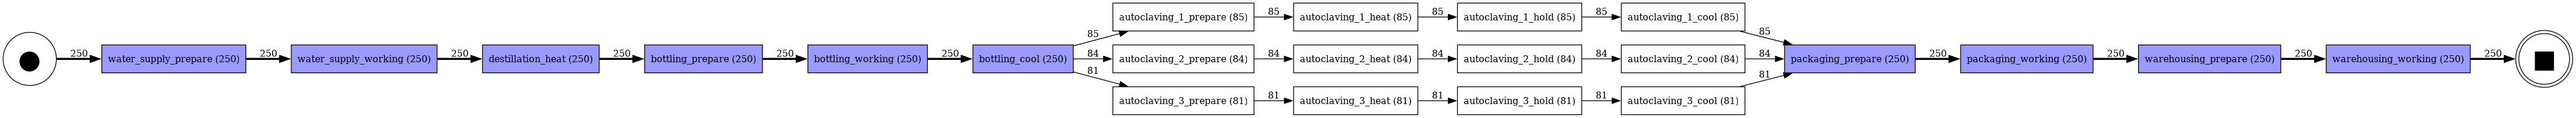


  DFG — SIMULATED LOG (alpha):


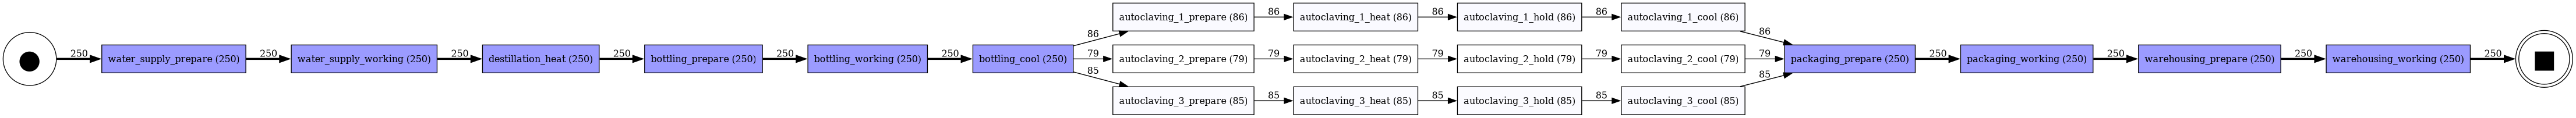

In [18]:
from IPython.display import Image, display as ipy_display
from pm4py.visualization.petri_net import visualizer as pn_vis
from pm4py.visualization.dfg import visualizer as dfg_vis

ALGORITHMS = ['inductive', 'heuristic', 'alpha']
results = []

def _run_simulation(stats_df, pp, process_models):
    sim = ProcessSimulation(activity_stats_df=stats_df, production_plan=pp,
                            mode='petri_net', process_models=process_models)
    return sim.run()

for algo in ALGORITHMS:
    print(f'\n{chr(61)*60}')
    print(f'  ALGORITHM: {algo.upper()}')
    print(f'{chr(61)*60}')

    stats_df, raw_df, process_models = extract_process(df_train, mining_algorithm=algo)

    # ── Part A: conformance (Petri net vs real log) ───────────────────────────
    fit_tr_list, prec_tr_list, gen_list, sim_list = [], [], [], []
    fit_te_list, prec_te_list = [], []
    seen_stations = set()
    for key, pm_entry in (process_models or {}).items():
        obj, obj_type, station = key
        if (obj_type, station) in seen_stations:
            continue
        seen_stations.add((obj_type, station))
        net_s, im_s, fm_s = pm_entry['net'], pm_entry['im'], pm_entry['fm']
        if station == 'sterilization_process':
            df_tr_st = df_train.copy()
            df_te_st = df_test.copy()
        else:
            df_tr_st = df_train[df_train['station'] == station].copy()
            df_te_st = df_test[df_test['station'] == station].copy()
        log_tr_st = to_pm4py_log(df_tr_st)
        log_te_st = to_pm4py_log(df_te_st)
        fit_tr_list.append(_fitness(log_tr_st, net_s, im_s, fm_s))
        prec_tr_list.append(_precision(log_tr_st, net_s, im_s, fm_s))
        fit_te_list.append(_fitness(log_te_st, net_s, im_s, fm_s))
        prec_te_list.append(_precision(log_te_st, net_s, im_s, fm_s))
        gen_list.append(_generalization(log_tr_st, net_s, im_s, fm_s))
        sim_list.append(_simplicity(net_s))

    fit_tr  = float(np.nanmean(fit_tr_list))
    prec_tr = float(np.nanmean(prec_tr_list))
    fit_te  = float(np.nanmean(fit_te_list))
    prec_te = float(np.nanmean(prec_te_list))
    gen_val = float(np.nanmean(gen_list))
    sim_val = float(np.nanmean(sim_list))

    print(f'\n  [A] Conformance ({len(seen_stations)} net(s)):')
    print(f'    TRAIN  fitness={fit_tr:.3f}  precision={prec_tr:.3f}  generalization={gen_val:.3f}  simplicity={sim_val:.3f}')
    print(f'    TEST   fitness={fit_te:.3f}  precision={prec_te:.3f}  generalization={gen_val:.3f}  simplicity={sim_val:.3f}')

    # ── Part B: simulation output vs real log ─────────────────────────────────
    pp_train = df_production_plan[df_production_plan['case_id'].isin(_train_cases)].copy()
    if pp_train.empty:
        pp_train = df_production_plan.copy()
    pp_test = df_production_plan[df_production_plan['case_id'].isin(_test_cases)].copy()
    if pp_test.empty:
        pp_test = df_production_plan.copy()

    try:
        sim_log_tr = _run_simulation(stats_df, pp_train, process_models)
        evt_ratio_tr            = _compute_event_ratio(sim_log_tr, df_train)
        mean_dur_tr, med_dur_tr = _compute_duration_errors(sim_log_tr, df_train)
        js_tr                   = _compute_js_divergence(sim_log_tr, df_train)
        edge_prec_tr, edge_rec_tr, edge_f1_tr = _compute_edge_metrics(sim_log_tr, df_train)
        print(f'\n  [B] Sim vs TRAIN:')
        print(f'    evt_ratio={evt_ratio_tr:.3f}  mean_dur_err={mean_dur_tr:.3f}  med_dur_err={med_dur_tr:.3f}')
        print(f'    js_div={js_tr:.3f}  edge_prec={edge_prec_tr:.3f}  edge_rec={edge_rec_tr:.3f}  edge_f1={edge_f1_tr:.3f}')
    except Exception as e:
        print(f'  [TRAIN SIM] failed: {e}')
        evt_ratio_tr = mean_dur_tr = med_dur_tr = np.nan
        js_tr = edge_prec_tr = edge_rec_tr = edge_f1_tr = np.nan

    sim_log_te = None
    try:
        sim_log_te = _run_simulation(stats_df, pp_test, process_models)
        evt_ratio_te            = _compute_event_ratio(sim_log_te, df_test)
        mean_dur_te, med_dur_te = _compute_duration_errors(sim_log_te, df_test)
        js_te                   = _compute_js_divergence(sim_log_te, df_test)
        edge_prec_te, edge_rec_te, edge_f1_te = _compute_edge_metrics(sim_log_te, df_test)
        act_dur_te = _compute_activity_duration_errors(sim_log_te, df_test)
        print(f'\n  [B] Sim vs TEST:')
        print(f'    evt_ratio={evt_ratio_te:.3f}  mean_dur_err={mean_dur_te:.3f}  med_dur_err={med_dur_te:.3f}')
        print(f'    js_div={js_te:.3f}  edge_prec={edge_prec_te:.3f}  edge_rec={edge_rec_te:.3f}  edge_f1={edge_f1_te:.3f}')
    except Exception as e:
        print(f'  [TEST SIM] failed: {e}')
        evt_ratio_te = mean_dur_te = med_dur_te = np.nan
        js_te = edge_prec_te = edge_rec_te = edge_f1_te = act_dur_te = np.nan

    results.append({
        'algo': algo,
        'train_fitness': fit_tr,   'train_precision': prec_tr,
        'train_generalization': gen_val, 'train_simplicity': sim_val,
        'train_evtratio': evt_ratio_tr,
        'train_meandurerr': mean_dur_tr, 'train_meddurerr': med_dur_tr,
        'train_jsdiv': js_tr,
        'train_edgeprec': edge_prec_tr, 'train_edgerec': edge_rec_tr, 'train_edgef1': edge_f1_tr,
        'test_fitness': fit_te,    'test_precision': prec_te,
        'test_generalization': gen_val,  'test_simplicity': sim_val,
        'test_evtratio': evt_ratio_te,
        'test_meandurerr': mean_dur_te,  'test_meddurerr': med_dur_te,
        'test_jsdiv': js_te,
        'test_edgeprec': edge_prec_te, 'test_edgerec': edge_rec_te, 'test_edgef1': edge_f1_te,
        'test_actdurerr': act_dur_te,
    })

    # ── Petri net visualisation ───────────────────────────────────────────────
    try:
        first_key = next(iter(process_models or {}))
        pm_vis    = process_models[first_key]
        log_train_pm4py = to_pm4py_log(df_train)
        gviz = pn_vis.apply(pm_vis['net'], pm_vis['im'], pm_vis['fm'],
                            variant=pn_vis.Variants.FREQUENCY,
                            parameters={'log': log_train_pm4py})
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
            pn_vis.save(gviz, f.name)
            obj_v, _, sta_v = first_key
            print(f'\n    Petri net ({algo} / {obj_v} - {sta_v}):')
            ipy_display(Image(filename=f.name))
    except Exception as e:
        print(f'    (Petri net visualisation failed: {e})')

    # ── DFG: real test set vs simulated log ───────────────────────────────────
    if sim_log_te is not None:
        try:
            test_fmt = _format_df(df_test)
            dfg_test, sa_test, ea_test = pm4py.discover_dfg(test_fmt)
            gviz_test = dfg_vis.apply(
                dfg_test, log=test_fmt, variant=dfg_vis.Variants.FREQUENCY,
                parameters={'start_activities': sa_test, 'end_activities': ea_test})
            with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
                dfg_vis.save(gviz_test, f.name)
                print(f'\n  DFG — REAL TEST SET ({algo}):')
                ipy_display(Image(filename=f.name))

            sim_fmt = _format_df(sim_log_te)
            dfg_sim, sa_sim, ea_sim = pm4py.discover_dfg(sim_fmt)
            gviz_sim = dfg_vis.apply(
                dfg_sim, log=sim_fmt, variant=dfg_vis.Variants.FREQUENCY,
                parameters={'start_activities': sa_sim, 'end_activities': ea_sim})
            with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
                dfg_vis.save(gviz_sim, f.name)
                print(f'\n  DFG — SIMULATED LOG ({algo}):')
                ipy_display(Image(filename=f.name))
        except Exception as e:
            print(f'  (DFG comparison failed: {e})')

,algo,train_fitness,train_precision,train_generalization,train_simplicity,train_evtratio,train_meandurerr,train_meddurerr,train_jsdiv,train_edgeprec,...,test_generalization,test_simplicity,test_evtratio,test_meandurerr,test_meddurerr,test_jsdiv,test_edgeprec,test_edgerec,test_edgef1,test_actdurerr
0,inductive,1.0,1.0,0.9115,0.9556,1.0,0.0097,0.038,0.0065,1.0,...,0.9115,0.9556,1.0,0.0429,0.248,0.0085,1.0,1.0,1.0,0.0959
1,heuristic,1.0,1.0,0.9115,0.9556,1.0,0.0097,0.038,0.0065,1.0,...,0.9115,0.9556,1.0,0.0429,0.248,0.0085,1.0,1.0,1.0,0.0959
2,alpha,1.0,1.0,0.9115,0.9556,1.0,0.0097,0.038,0.0065,1.0,...,0.9115,0.9556,1.0,0.0429,0.248,0.0085,1.0,1.0,1.0,0.0959


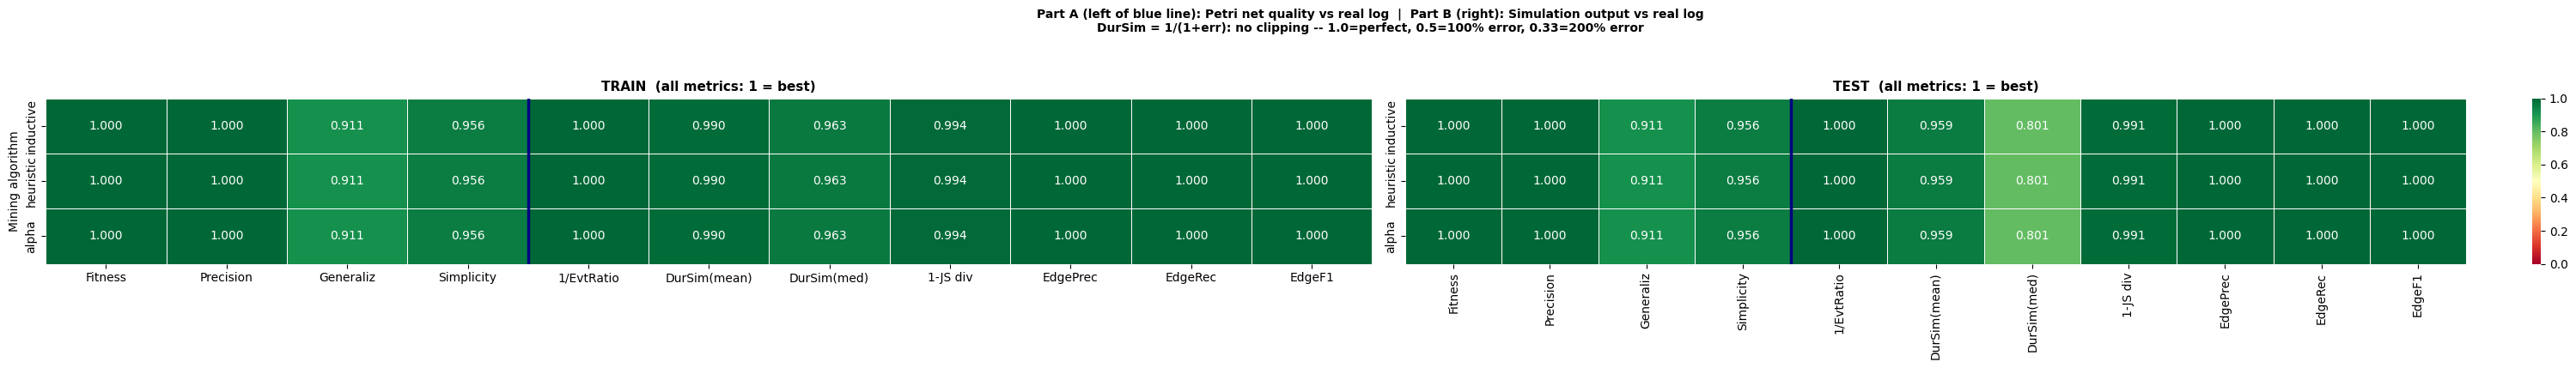


Raw duration errors (before transformation):
  inductive     train: mean=0.010  med=0.038  |  test: mean=0.043  med=0.248
  heuristic     train: mean=0.010  med=0.038  |  test: mean=0.043  med=0.248
  alpha         train: mean=0.010  med=0.038  |  test: mean=0.043  med=0.248


In [19]:
res_df = pd.DataFrame(results)
display(res_df.round(4))

if not res_df.empty:
    COLS_A = ['fitness', 'precision', 'generalization', 'simplicity']
    COLS_B = ['evtratio', 'meandurerr', 'meddurerr', 'jsdiv', 'edgeprec', 'edgerec', 'edgef1']
    ALL_COLS = COLS_A + COLS_B

    LABELS = [
        'Fitness', 'Precision', 'Generaliz', 'Simplicity',
        '1/EvtRatio',      # 1.0 when ratio=1.0
        'DurSim(mean)',    # 1/(1+err): 1.0=perfect, 0.5=100% off, never clips to 0
        'DurSim(med)',     # same, median-based
        '1-JS div',        # 1.0 when distributions identical
        'EdgePrec', 'EdgeRec', 'EdgeF1',
    ]

    def _to_heatmap(res_df, split):
        hm = res_df.set_index('algo')[[f'{split}_{c}' for c in ALL_COLS]].copy().astype(float)
        # EvtRatio: 1/r, clipped at 1 (over-generation beyond 2x shown as 0.5)
        col = f'{split}_evtratio'
        hm[col] = (1.0 / hm[col].replace(0, np.nan)).clip(0, 1)
        # Duration errors: 1/(1+err) — no clipping, naturally in (0, 1]
        for c in ('meandurerr', 'meddurerr'):
            col = f'{split}_{c}'
            hm[col] = 1.0 / (1.0 + hm[col])
        # JS div: 1 - value (max ~0.83 so floor is ~0.17)
        col = f'{split}_jsdiv'
        hm[col] = (1.0 - hm[col]).clip(0, 1)
        hm.columns = LABELS
        return hm

    train_hm = _to_heatmap(res_df, 'train')
    test_hm  = _to_heatmap(res_df, 'test')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(32, max(3, len(res_df) + 1)))

    sns.heatmap(train_hm.round(3), annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=0.5, cbar=False, ax=ax1)
    ax1.set_title('TRAIN  (all metrics: 1 = best)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Mining algorithm')
    ax1.axvline(x=len(COLS_A), color='navy', linewidth=2.5)

    sns.heatmap(test_hm.round(3), annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, linewidths=0.5, ax=ax2)
    ax2.set_title('TEST  (all metrics: 1 = best)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('')
    ax2.axvline(x=len(COLS_A), color='navy', linewidth=2.5)

    plt.suptitle(
        'Part A (left of blue line): Petri net quality vs real log  |  '
        'Part B (right): Simulation output vs real log\n'
        'DurSim = 1/(1+err): no clipping -- 1.0=perfect, 0.5=100% error, 0.33=200% error',
        fontsize=10, fontweight='bold', y=1.06)
    plt.tight_layout()
    plt.show()

    print('\nRaw duration errors (before transformation):')
    for _, row in res_df.iterrows():
        print(f"  {row['algo']:12s}  train: mean={row['train_meandurerr']:.3f}  med={row['train_meddurerr']:.3f}"
              f"  |  test: mean={row['test_meandurerr']:.3f}  med={row['test_meddurerr']:.3f}")


  INDUCTIVE

Processing: sterilization_process (8 objects, one whole-process net)
  Mining algorithm: inductive
  Found 22 unique activities: ['water_supply_prepare' 'water_supply_working' 'destillation_heat'
 'bottling_prepare' 'bottling_working' 'bottling_cool'
 'autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_2_prepare'
 'autoclaving_2_heat' 'autoclaving_1_hold' 'autoclaving_3_prepare'
 'autoclaving_3_heat' 'autoclaving_2_hold' 'autoclaving_1_cool'
 'autoclaving_2_cool' 'autoclaving_3_hold' 'packaging_prepare'
 'autoclaving_3_cool' 'packaging_working' 'warehousing_prepare'
 'warehousing_working']
    water_supply_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
    water_supply_working: best fit = weibull_min (3.307345386537942, 0.0, 1.3267222301619117)
    destillation_heat: best fit = weibull_min (3.2903830188083383, 0.0, 0.663379508518636)
    bottling_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
    bottling

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9668, fitness=1.0000, precision=1.0000, generalization=0.9114997548898552, simplicity=0.9555555555555555
    Selected params: noise=0.2, heur={} (score=0.9668)
    Petri net: 21 places, 22 transitions, 44 arcs


replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

    Stochastic map: 22 transition weights
    Decision-point weights: 20 decision points, 0 with __END__ probability
    Max case length in training: 14
      water_supply_prepare: Start=True, End=False, Transitions={'water_supply_working': 1.0}
      water_supply_working: Start=False, End=False, Transitions={'destillation_heat': 1.0}
      destillation_heat: Start=False, End=False, Transitions={'bottling_prepare': 1.0}
      bottling_prepare: Start=False, End=False, Transitions={'bottling_working': 1.0}
      bottling_working: Start=False, End=False, Transitions={'bottling_cool': 1.0}
      bottling_cool: Start=False, End=False, Transitions={'autoclaving_1_prepare': 0.336, 'autoclaving_2_prepare': 0.332, 'autoclaving_3_prepare': 0.332}
      autoclaving_1_prepare: Start=False, End=False, Transitions={'autoclaving_1_heat': 1.0}
      autoclaving_1_heat: Start=False, End=False, Transitions={'autoclaving_1_hold': 1.0}
      autoclaving_2_prepare: Start=False, End=False, Transitions={'aut

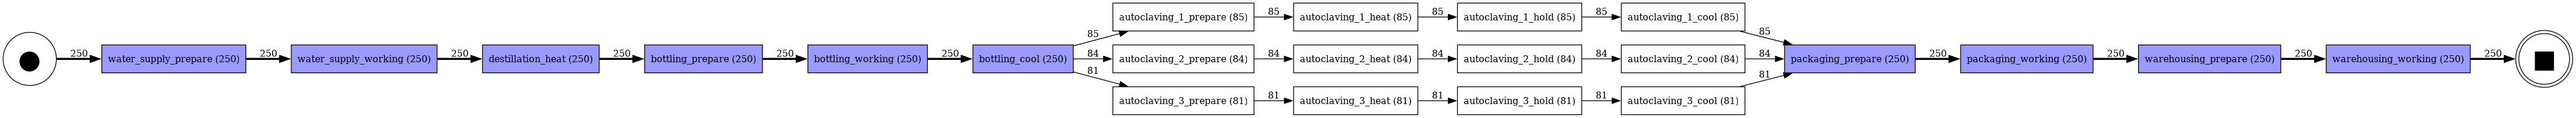


SIMULATED LOG — inductive:


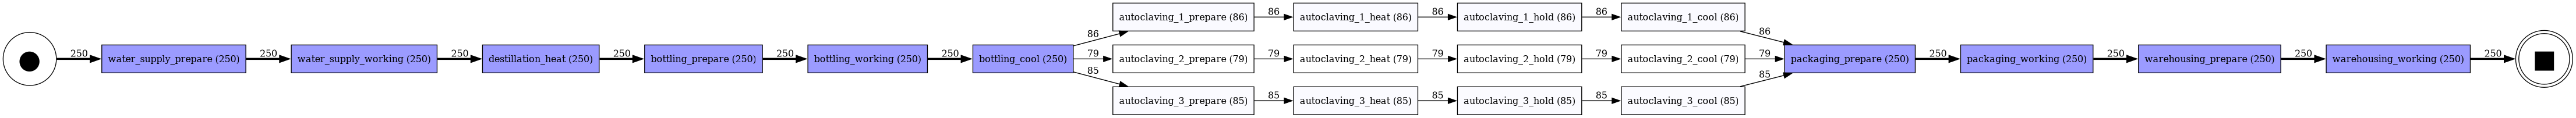


  HEURISTIC

Processing: sterilization_process (8 objects, one whole-process net)
  Mining algorithm: heuristic
  Found 22 unique activities: ['water_supply_prepare' 'water_supply_working' 'destillation_heat'
 'bottling_prepare' 'bottling_working' 'bottling_cool'
 'autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_2_prepare'
 'autoclaving_2_heat' 'autoclaving_1_hold' 'autoclaving_3_prepare'
 'autoclaving_3_heat' 'autoclaving_2_hold' 'autoclaving_1_cool'
 'autoclaving_2_cool' 'autoclaving_3_hold' 'packaging_prepare'
 'autoclaving_3_cool' 'packaging_working' 'warehousing_prepare'
 'warehousing_working']
    water_supply_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
    water_supply_working: best fit = weibull_min (3.307345386537942, 0.0, 1.3267222301619117)
    destillation_heat: best fit = weibull_min (3.2903830188083383, 0.0, 0.663379508518636)
    bottling_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
    bottling

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9668, fitness=1.0000, precision=1.0000, generalization=0.9114997548898552, simplicity=0.9555555555555555
    Selected params: noise=0.2, heur={} (score=0.9668)
    Petri net: 21 places, 22 transitions, 44 arcs


replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

    Stochastic map: 22 transition weights
    Decision-point weights: 20 decision points, 0 with __END__ probability
    Max case length in training: 14
      water_supply_prepare: Start=True, End=False, Transitions={'water_supply_working': 1.0}
      water_supply_working: Start=False, End=False, Transitions={'destillation_heat': 1.0}
      destillation_heat: Start=False, End=False, Transitions={'bottling_prepare': 1.0}
      bottling_prepare: Start=False, End=False, Transitions={'bottling_working': 1.0}
      bottling_working: Start=False, End=False, Transitions={'bottling_cool': 1.0}
      bottling_cool: Start=False, End=False, Transitions={'autoclaving_1_prepare': 0.336, 'autoclaving_2_prepare': 0.332, 'autoclaving_3_prepare': 0.332}
      autoclaving_1_prepare: Start=False, End=False, Transitions={'autoclaving_1_heat': 1.0}
      autoclaving_1_heat: Start=False, End=False, Transitions={'autoclaving_1_hold': 1.0}
      autoclaving_2_prepare: Start=False, End=False, Transitions={'aut

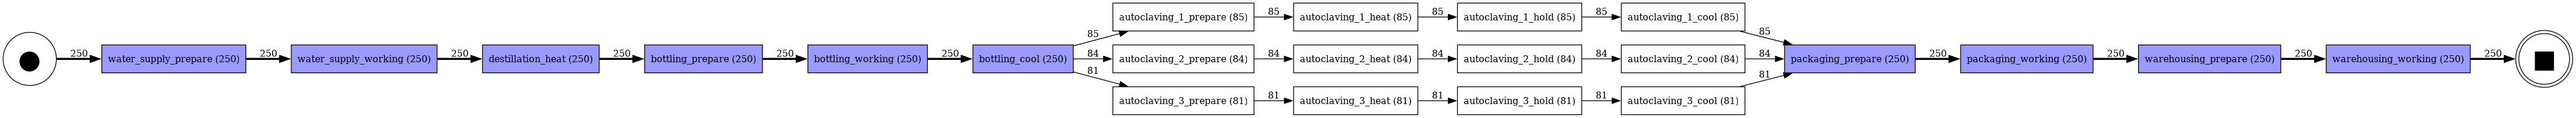


SIMULATED LOG — heuristic:


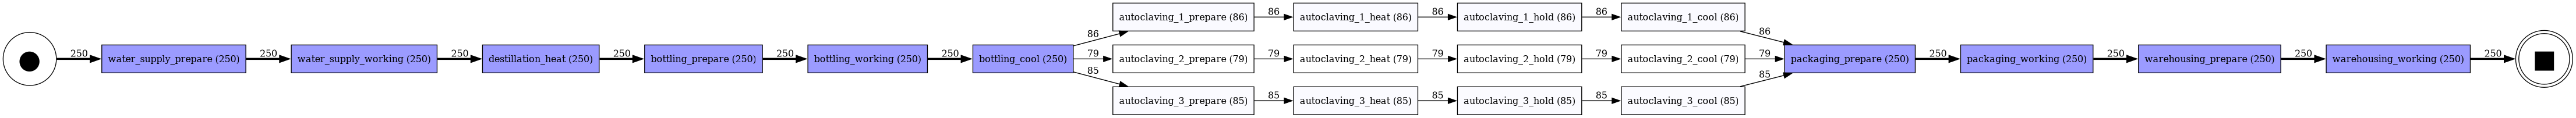


  ALPHA

Processing: sterilization_process (8 objects, one whole-process net)
  Mining algorithm: alpha
  Found 22 unique activities: ['water_supply_prepare' 'water_supply_working' 'destillation_heat'
 'bottling_prepare' 'bottling_working' 'bottling_cool'
 'autoclaving_1_prepare' 'autoclaving_1_heat' 'autoclaving_2_prepare'
 'autoclaving_2_heat' 'autoclaving_1_hold' 'autoclaving_3_prepare'
 'autoclaving_3_heat' 'autoclaving_2_hold' 'autoclaving_1_cool'
 'autoclaving_2_cool' 'autoclaving_3_hold' 'packaging_prepare'
 'autoclaving_3_cool' 'packaging_working' 'warehousing_prepare'
 'warehousing_working']
    water_supply_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
    water_supply_working: best fit = weibull_min (3.307345386537942, 0.0, 1.3267222301619117)
    destillation_heat: best fit = weibull_min (3.2903830188083383, 0.0, 0.663379508518636)
    bottling_prepare: best fit = weibull_min (3.297853069533603, 0.0, 0.11060110710272478)
    bottling_working

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/27 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

      quality: score=0.9668, fitness=1.0000, precision=1.0000, generalization=0.9114997548898552, simplicity=0.9555555555555555
    Selected params: noise=0.2, heur={} (score=0.9668)
    Petri net: 21 places, 22 transitions, 44 arcs


replaying log with TBR, completed traces ::   0%|          | 0/3 [00:00<?, ?it/s]

    Stochastic map: 22 transition weights
    Decision-point weights: 20 decision points, 0 with __END__ probability
    Max case length in training: 14
      water_supply_prepare: Start=True, End=False, Transitions={'water_supply_working': 1.0}
      water_supply_working: Start=False, End=False, Transitions={'destillation_heat': 1.0}
      destillation_heat: Start=False, End=False, Transitions={'bottling_prepare': 1.0}
      bottling_prepare: Start=False, End=False, Transitions={'bottling_working': 1.0}
      bottling_working: Start=False, End=False, Transitions={'bottling_cool': 1.0}
      bottling_cool: Start=False, End=False, Transitions={'autoclaving_1_prepare': 0.336, 'autoclaving_2_prepare': 0.332, 'autoclaving_3_prepare': 0.332}
      autoclaving_1_prepare: Start=False, End=False, Transitions={'autoclaving_1_heat': 1.0}
      autoclaving_1_heat: Start=False, End=False, Transitions={'autoclaving_1_hold': 1.0}
      autoclaving_2_prepare: Start=False, End=False, Transitions={'aut

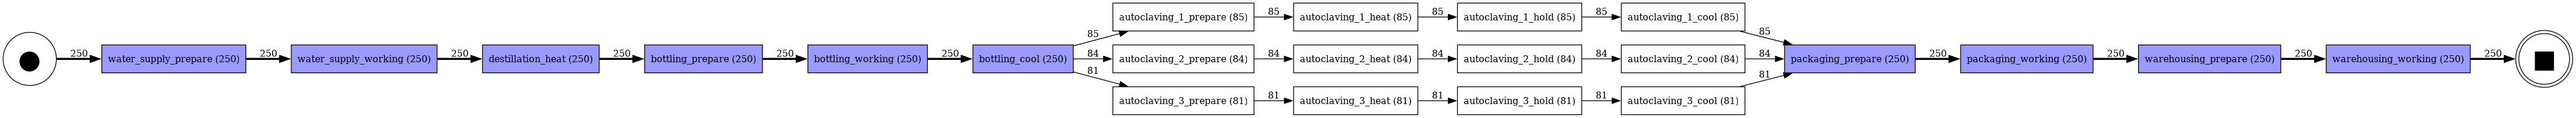


SIMULATED LOG — alpha:


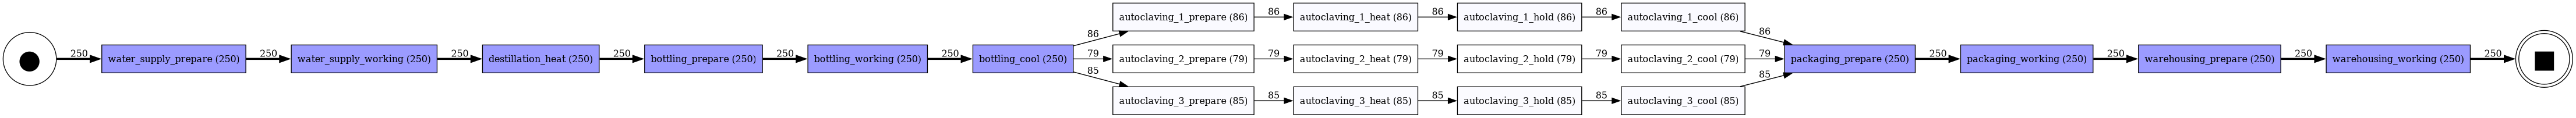

In [20]:
from pm4py.visualization.dfg import visualizer as dfg_vis
import tempfile
from IPython.display import Image, display as ipy_display

pp_test_dfg = df_production_plan[df_production_plan['case_id'].isin(_test_cases)].copy()
if pp_test_dfg.empty:
    pp_test_dfg = df_production_plan.copy()

# Pre-compute real test DFG once (same for all algorithms)
test_fmt = _format_df(df_test)
dfg_test, sa_test, ea_test = pm4py.discover_dfg(test_fmt)
gviz_test = dfg_vis.apply(
    dfg_test, log=test_fmt, variant=dfg_vis.Variants.FREQUENCY,
    parameters={'start_activities': sa_test, 'end_activities': ea_test})

for algo in ALGORITHMS:
    print(f'\n{"="*60}')
    print(f'  {algo.upper()}')
    print(f'{"="*60}')

    # Re-extract so we have process_models and stats for this algo
    stats_df_v, _, pm_v = extract_process(df_train, mining_algorithm=algo)

    sim_v = ProcessSimulation(activity_stats_df=stats_df_v, production_plan=pp_test_dfg,
                              mode='petri_net', process_models=pm_v)
    sim_log_v = sim_v.run()

    print(f'  Sim events: {len(sim_log_v)}  |  Real test events: {len(df_test)}')

    # ── Real test DFG ─────────────────────────────────────────────────────────
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
        dfg_vis.save(gviz_test, f.name)
        print(f'\nREAL TEST SET — {algo}:')
        ipy_display(Image(filename=f.name))

    # ── Simulated log DFG ─────────────────────────────────────────────────────
    sim_fmt = _format_df(sim_log_v)
    dfg_sim, sa_sim, ea_sim = pm4py.discover_dfg(sim_fmt)
    gviz_sim = dfg_vis.apply(
        dfg_sim, log=sim_fmt, variant=dfg_vis.Variants.FREQUENCY,
        parameters={'start_activities': sa_sim, 'end_activities': ea_sim})
    with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as f:
        dfg_vis.save(gviz_sim, f.name)
        print(f'\nSIMULATED LOG — {algo}:')
        ipy_display(Image(filename=f.name))

## DFG comparison: real test set vs simulated log

One DFG pair per algorithm — run the cell below after cell-31 completes.


=== Metric definitions ===


,Formula,Inputs,Interpretation
Metric,,,
EvtRatioErr (0=best),|n_sim / n_real − 1|,n_sim = simulated events; n_real = real test e...,0 = exact event count; no clipping needed
DurErr(whole) (0=best),|mean_dur_sim − mean_dur_real| / mean_dur_...,mean duration across ALL events in the log,0 = identical mean; 0.05 = 5% off; unbounded a...
DurErr(activ) (0=best),mean over activities of |sim_act − real_act...,per-activity mean duration (e.g. autoclaving_1...,0 = all activities match; reveals per-step tim...
JS div (0=best),"JensenShannon(sim_activity_freq, real_activit...",normalised activity frequency distributions,0 = identical mix of activities; 1 = completel...
1-EdgeF1 (0=best),1 − 2·P·R / (P+R) where P=|sim∩real|/|sim|...,directly-follows edges from DFG of sim log vs ...,0 = identical process structure; 1 = no common...
Overall (0=best),"mean(EvtRatioErr, DurErr_whole, DurErr_activ, ...",the five metrics above,0 = perfect simulation across all dimensions



=== Process Results (Short) — Test Set ===


,EvtRatioErr,DurErr(whole),DurErr(activ),JS div,1-EdgeF1,Overall
algo,,,,,,
inductive,0.0,0.0429,0.0959,0.0085,0.0,0.0295
heuristic,0.0,0.0429,0.0959,0.0085,0.0,0.0295
alpha,0.0,0.0429,0.0959,0.0085,0.0,0.0295


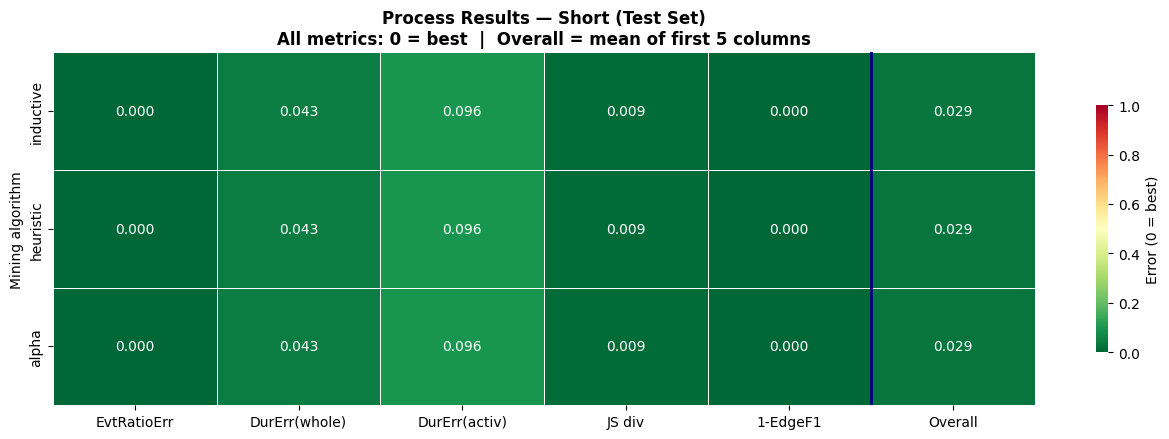

In [21]:
# ── Short results heatmap (test set, selected metrics + overall) ─────────────
res_df_short = pd.DataFrame(results)

if not res_df_short.empty:
    _metric_guide = pd.DataFrame([
        {
            'Metric':        'EvtRatioErr  (0=best)',
            'Formula':       '|n_sim / n_real  −  1|',
            'Inputs':        'n_sim = simulated events; n_real = real test events',
            'Interpretation':'0 = exact event count; no clipping needed',
        },
        {
            'Metric':        'DurErr(whole)  (0=best)',
            'Formula':       '|mean_dur_sim  −  mean_dur_real|  /  mean_dur_real',
            'Inputs':        'mean duration across ALL events in the log',
            'Interpretation':'0 = identical mean; 0.05 = 5% off; unbounded above',
        },
        {
            'Metric':        'DurErr(activ)  (0=best)',
            'Formula':       'mean over activities of  |sim_act  −  real_act|  /  real_act',
            'Inputs':        'per-activity mean duration (e.g. autoclaving_1_heat separately)',
            'Interpretation':'0 = all activities match; reveals per-step timing errors',
        },
        {
            'Metric':        'JS div  (0=best)',
            'Formula':       'JensenShannon(sim_activity_freq,  real_activity_freq)',
            'Inputs':        'normalised activity frequency distributions',
            'Interpretation':'0 = identical mix of activities; 1 = completely different',
        },
        {
            'Metric':        '1-EdgeF1  (0=best)',
            'Formula':       '1  −  2·P·R / (P+R)   where P=|sim∩real|/|sim|,  R=|sim∩real|/|real|',
            'Inputs':        'directly-follows edges from DFG of sim log vs real test log',
            'Interpretation':'0 = identical process structure; 1 = no common transitions',
        },
        {
            'Metric':        'Overall  (0=best)',
            'Formula':       'mean(EvtRatioErr, DurErr_whole, DurErr_activ, JS_div, 1-EdgeF1)',
            'Inputs':        'the five metrics above',
            'Interpretation':'0 = perfect simulation across all dimensions',
        },
    ]).set_index('Metric')

    print('\n=== Metric definitions ===')
    display(_metric_guide)

    def _build_short_hm(res_df):
        hm = pd.DataFrame(index=res_df['algo'])

        er = res_df.set_index('algo')['test_evtratio'].astype(float)
        hm['EvtRatioErr']   = (er - 1.0).abs()
        hm['DurErr(whole)'] = res_df.set_index('algo')['test_meandurerr'].astype(float)
        hm['DurErr(activ)'] = res_df.set_index('algo')['test_actdurerr'].astype(float)
        hm['JS div']        = res_df.set_index('algo')['test_jsdiv'].astype(float)
        hm['1-EdgeF1']      = 1.0 - res_df.set_index('algo')['test_edgef1'].astype(float)

        hm['Overall'] = hm[['EvtRatioErr', 'DurErr(whole)', 'DurErr(activ)', 'JS div', '1-EdgeF1']].mean(axis=1)

        return hm

    short_hm = _build_short_hm(res_df_short)

    print('\n=== Process Results (Short) — Test Set ===')
    display(short_hm.round(4))

    n_rows = max(2, len(res_df_short))
    fig, ax = plt.subplots(figsize=(13, n_rows * 0.9 + 1.8))
    sns.heatmap(short_hm.round(3), annot=True, fmt='.3f', cmap='RdYlGn_r',
                vmin=0, vmax=1, linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Error (0 = best)', 'shrink': 0.7}, ax=ax)
    ax.axvline(x=5, color='navy', linewidth=2.0)  # separator before Overall
    ax.set_title('Process Results — Short (Test Set)\n'
                 'All metrics: 0 = best  |  Overall = mean of first 5 columns',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Mining algorithm')
    plt.tight_layout()
    plt.show()
